In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os


bigtable_path = "../rsidis_bigtable_pass0.csv"

fit_files = {
    "H.cer": "H.cer.npeSum_fit_geometric_chi2.csv",
    "P.hgcer": "P.hgcer.npeSum_fit_geometric_chi2.csv",
    "P.aero": "P.aero.npeSum_fit_geometric_chi2.csv",
}

target_colors = {
    "LH2": cm.get_cmap("tab20")(0),
    "LD2": cm.get_cmap("tab20")(2),
    "Dummy": cm.get_cmap("tab20")(4),
    "C": cm.get_cmap("tab20")(6),
    "Cu": cm.get_cmap("tab20")(8),
}

output_dir = "fit_plots"
os.makedirs(output_dir, exist_ok=True)

bigtable = pd.read_csv(bigtable_path)
bigtable["run"] = bigtable["run"].astype(int)

fit_data = {}
for name, path in fit_files.items():
    df = pd.read_csv(path)
    df["run"] = df["run"].astype(int)

    # Compute mean_err if needed
    df["mean_err"] = (df["std_dev"] / np.sqrt(df.get("nevents", len(df))))
    df["mean_err"] = df["mean_err"].clip(lower=0).fillna(0)
    # Compute chi2/ndf safely
    if "chi2" in df.columns and "ndf" in df.columns:
        df["chi2_ndf"] = df["chi2"] / df["ndf"]
    else:
        print(f"WARNING: {name} file has no chi2 or ndf column — all runs will be classified as BAD.")
        df["chi2_ndf"] = np.inf  # forces classification as bad

    fit_data[name] = df



/var/folders/j6/9gzqgwz92nzg7mgfgbs2rxjm0000gn/T/ipykernel_16683/319775419.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "LH2": cm.get_cmap("tab20")(0),
/var/folders/j6/9gzqgwz92nzg7mgfgbs2rxjm0000gn/T/ipykernel_16683/319775419.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "LD2": cm.get_cmap("tab20")(2),
/var/folders/j6/9gzqgwz92nzg7mgfgbs2rxjm0000gn/T/ipykernel_16683/319775419.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "Dummy": cm.get_cm

## 4-pass:

### $\pi^-$ Setting 1:

H.cer Weighted Mean = 8.953 ± 0.256
P.hgcer Weighted Mean = 1.136 ± 0.252
P.aero Weighted Mean = 8.026 ± 0.447


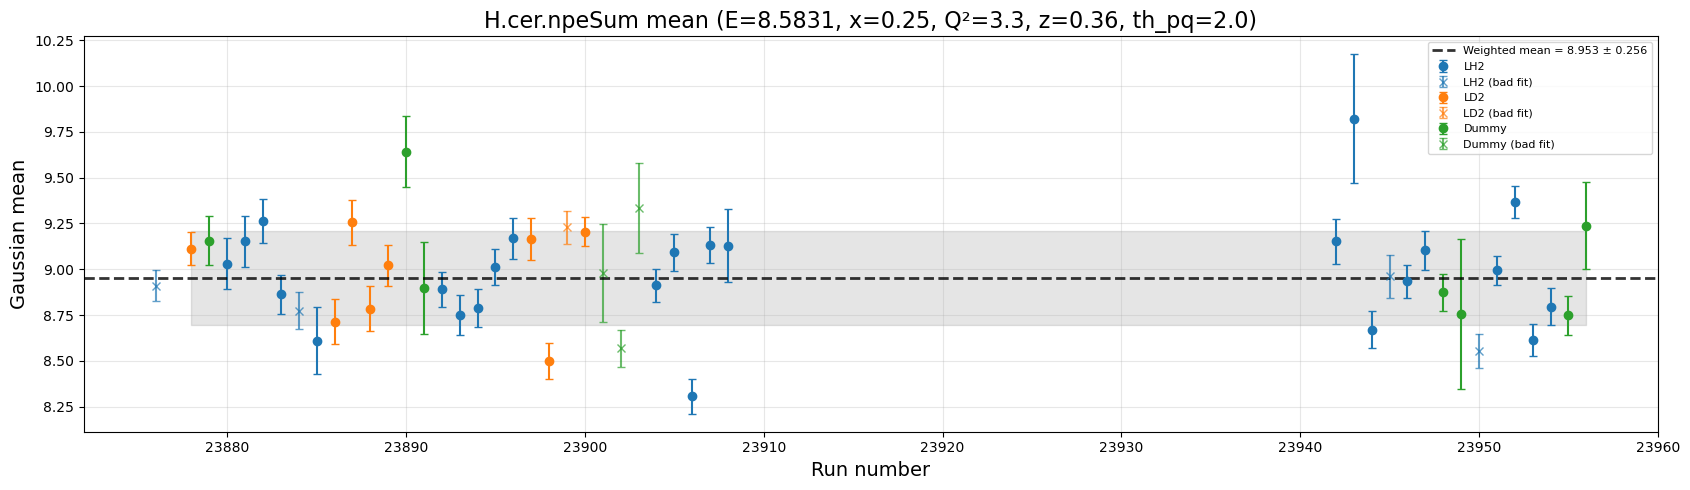

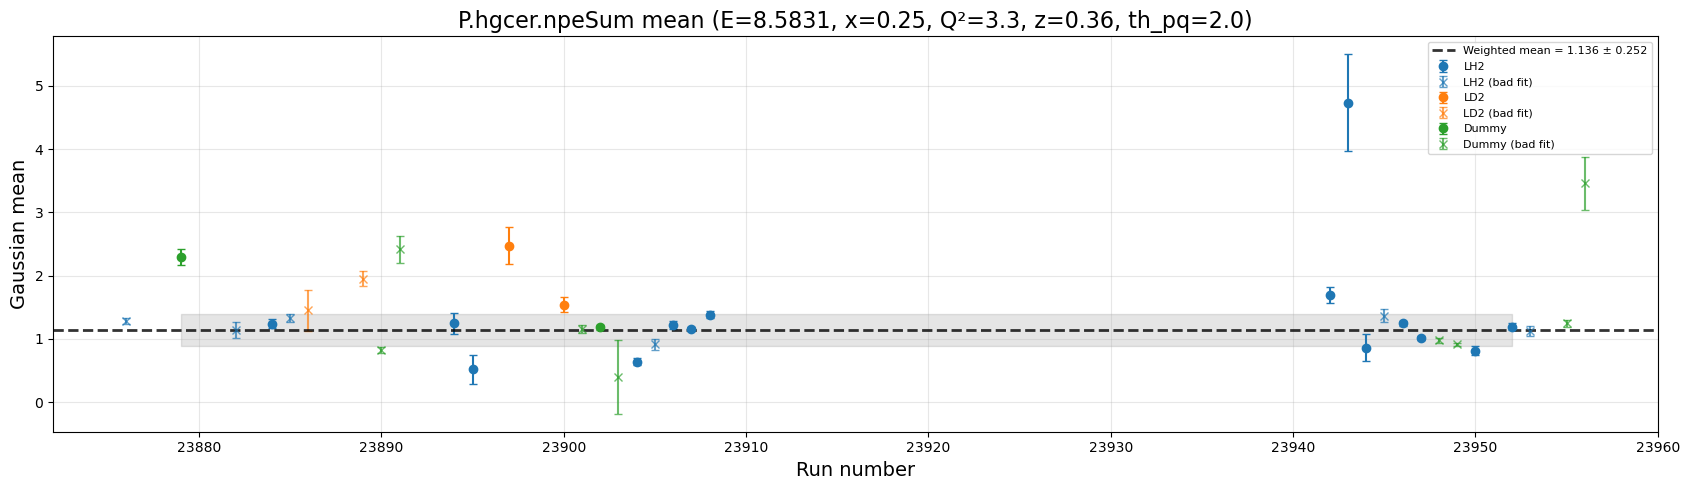

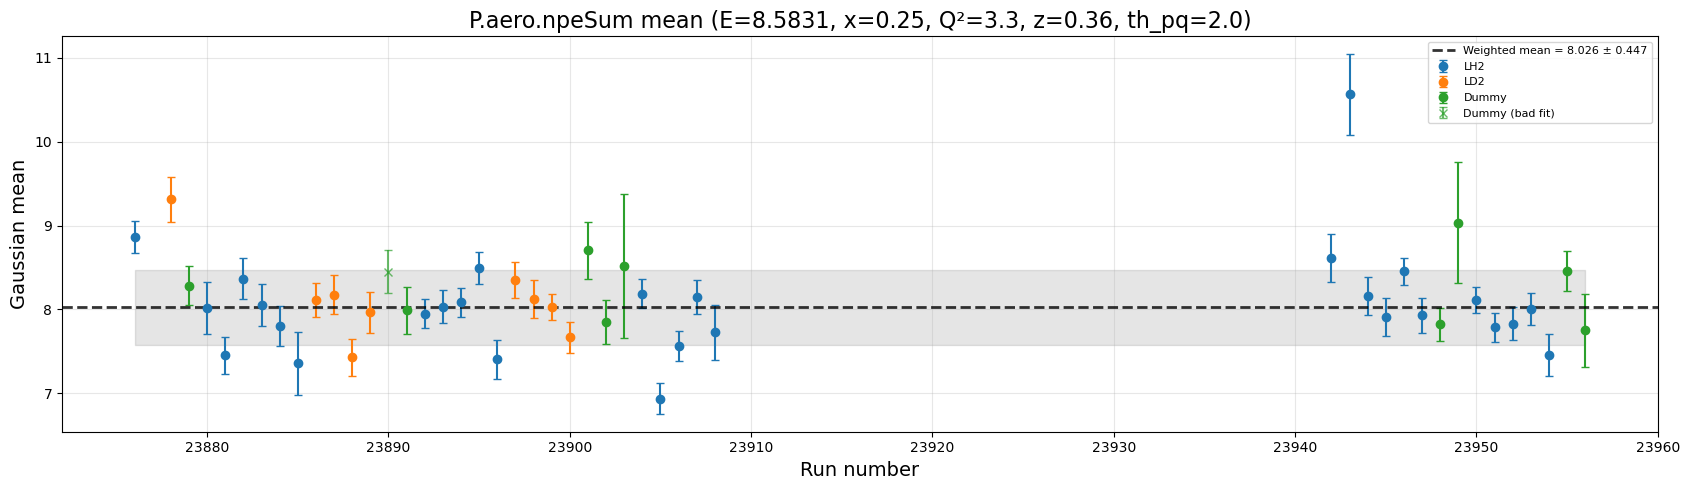

In [37]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.36
thpq = 2.0
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 2:

H.cer Weighted Mean = 8.924 ± 0.189
P.hgcer Weighted Mean = 11.900 ± 0.599
P.aero Weighted Mean = 7.945 ± 0.435


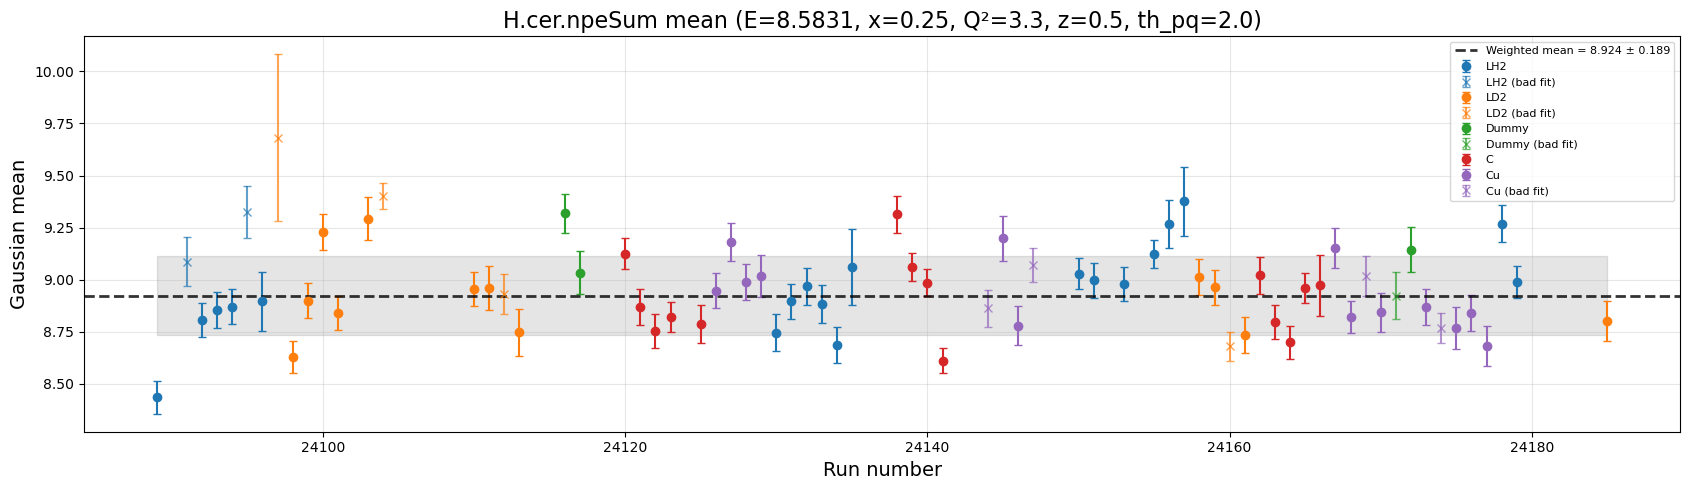

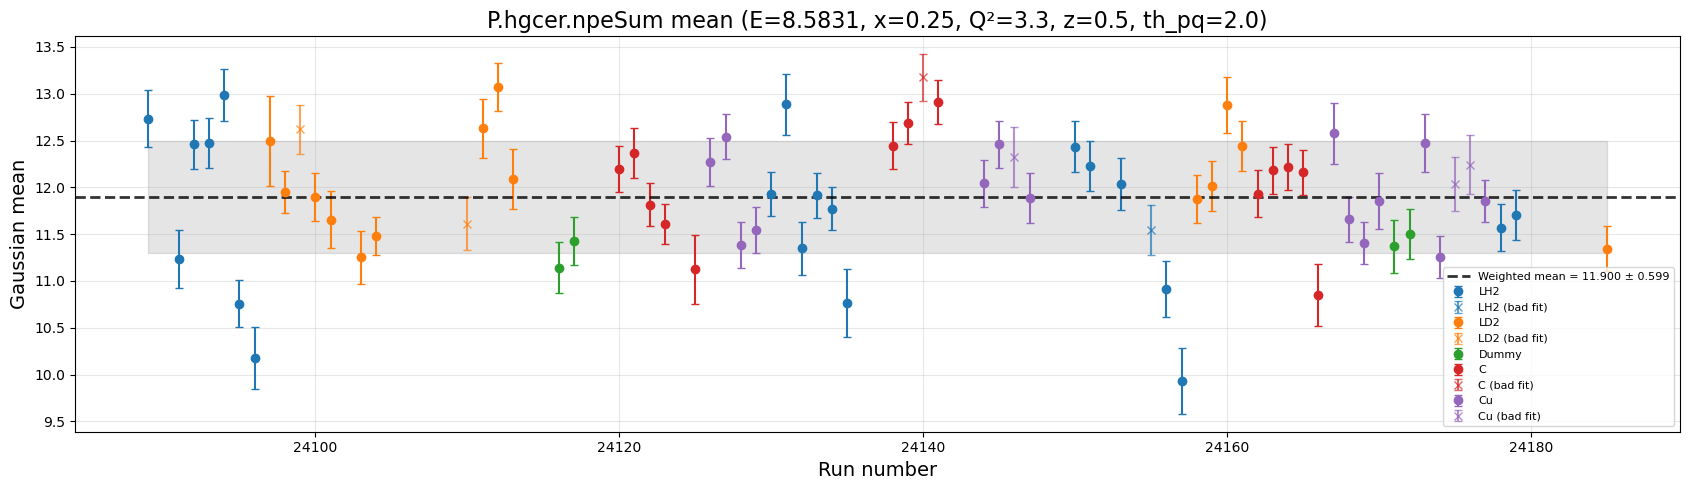

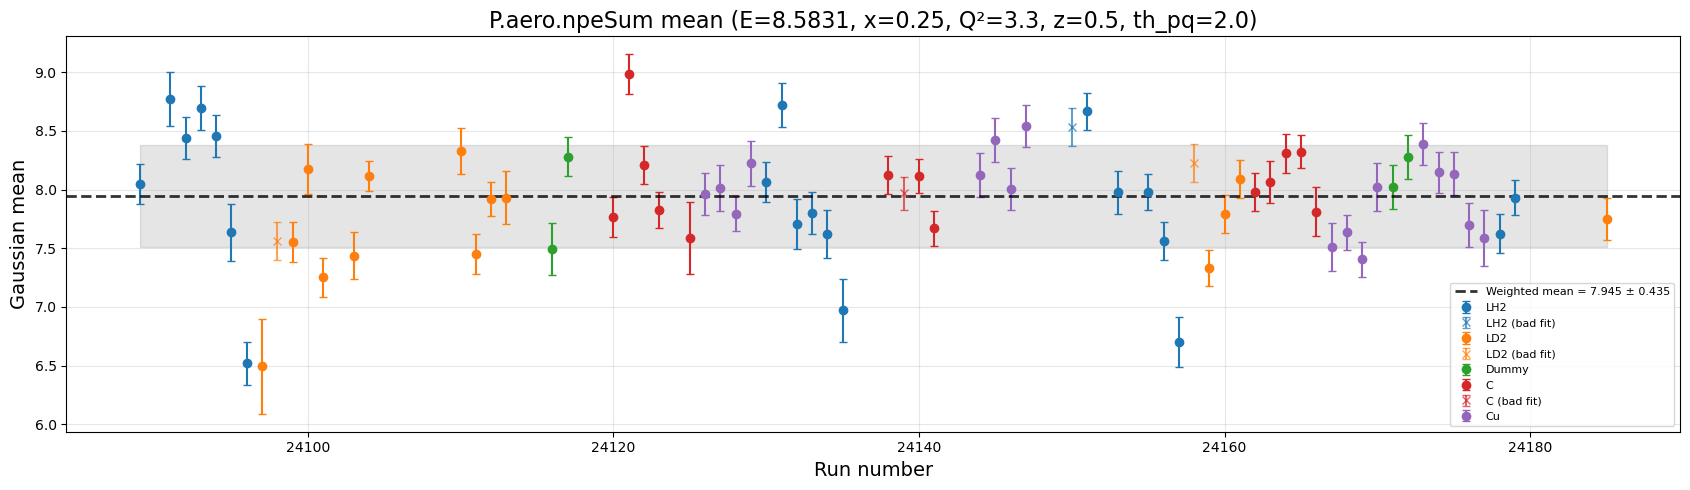

In [38]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 2.0
run_type = "PI-SIDIS"


mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 3

H.cer Weighted Mean = 9.000 ± 0.249
P.hgcer Weighted Mean = 19.844 ± 1.602
P.aero Weighted Mean = 8.375 ± 0.499


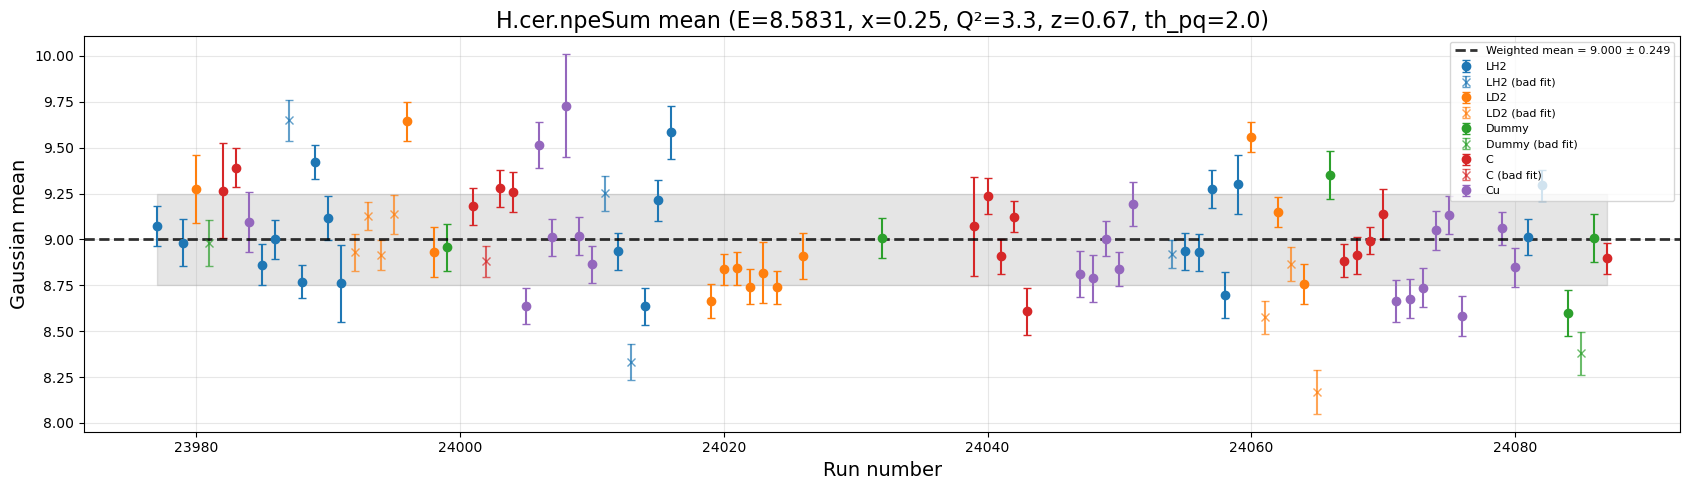

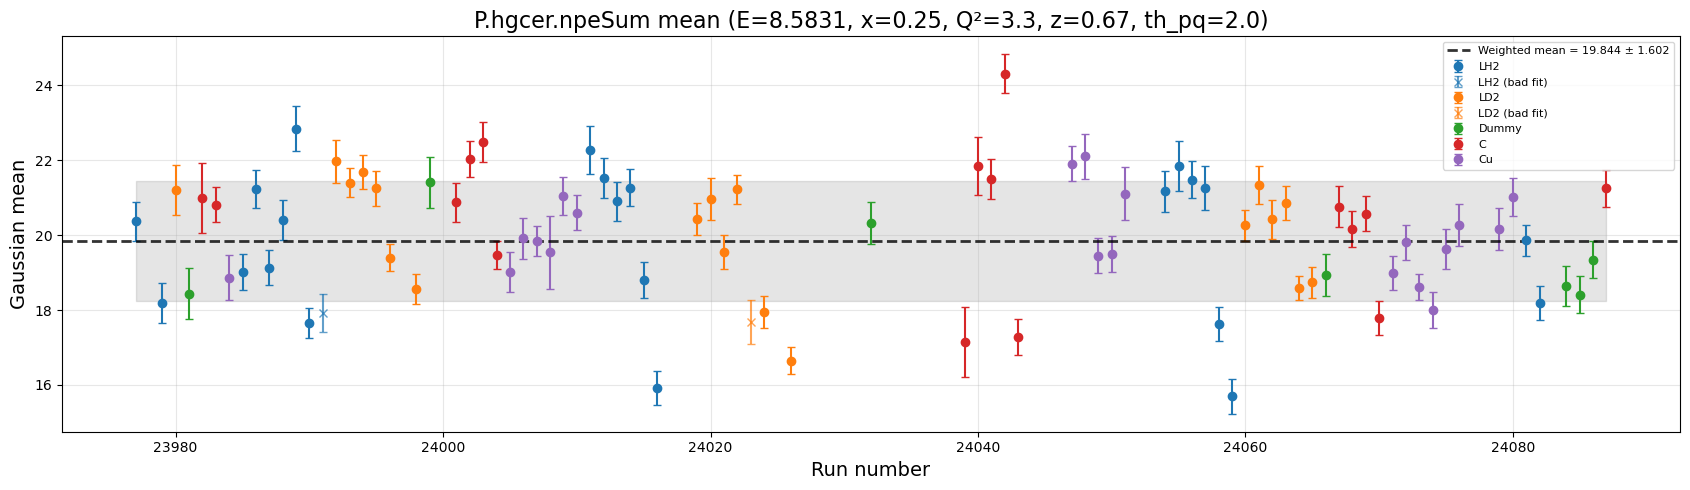

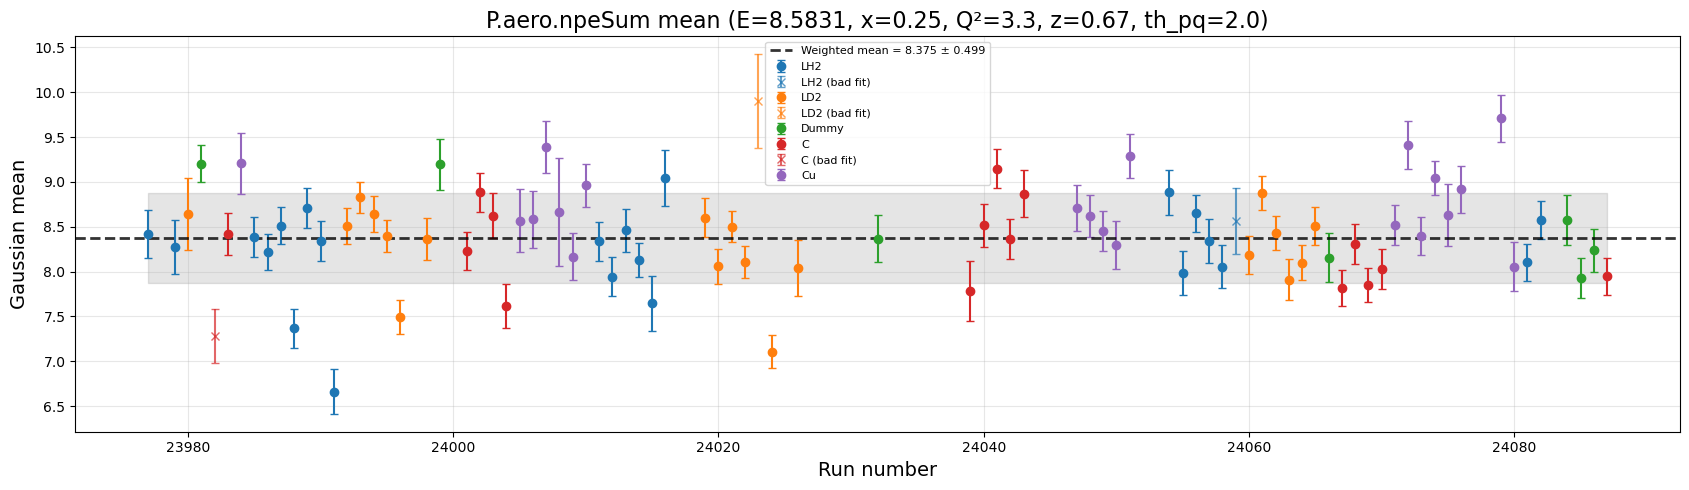

In [39]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.67
thpq = 2.0
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 4:

H.cer Weighted Mean = 9.136 ± 0.552
P.hgcer Weighted Mean = 23.149 ± 1.804
P.aero Weighted Mean = 9.477 ± 0.531


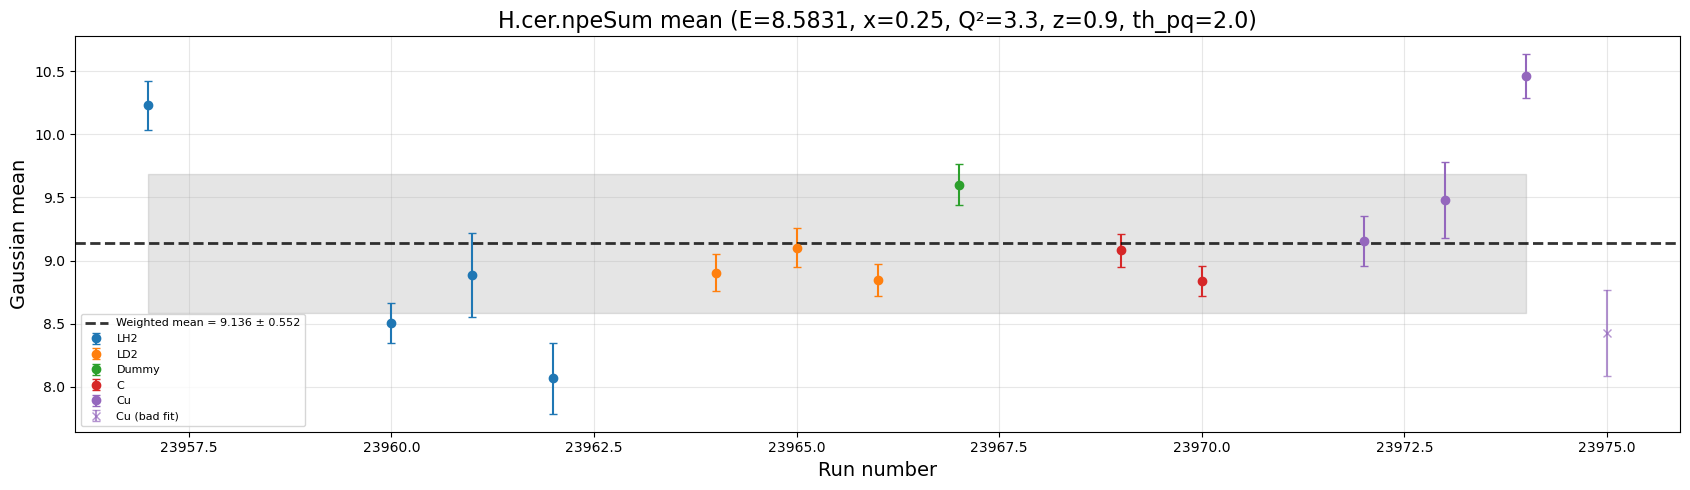

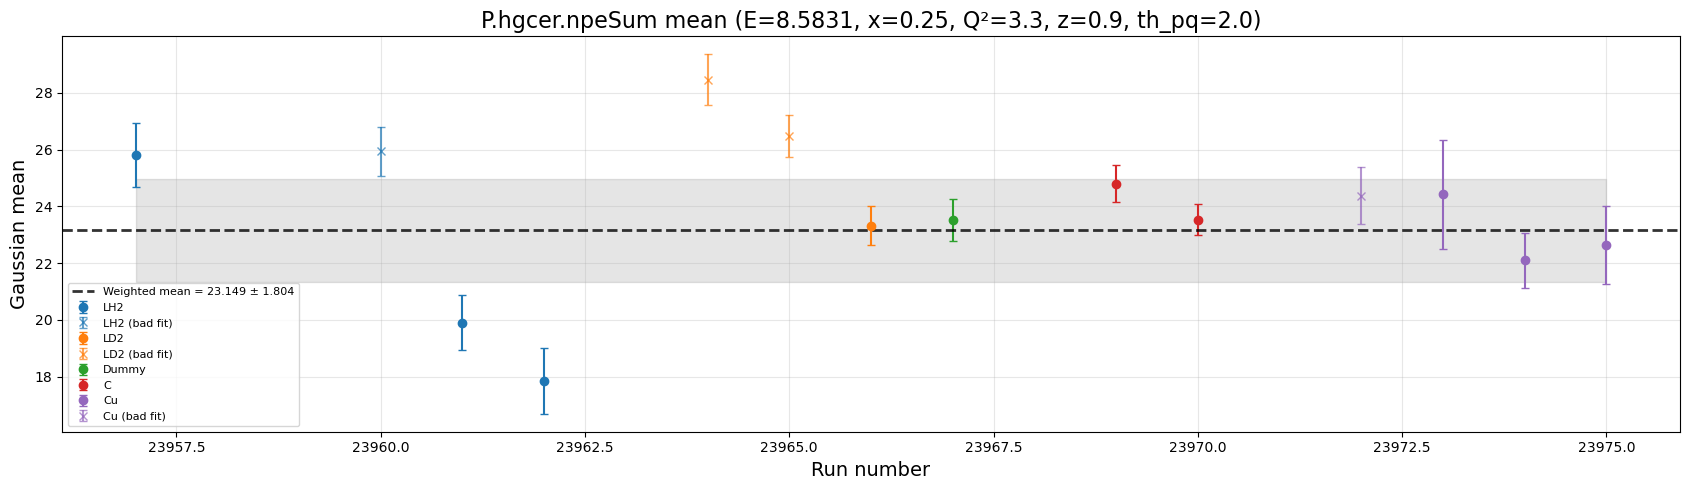

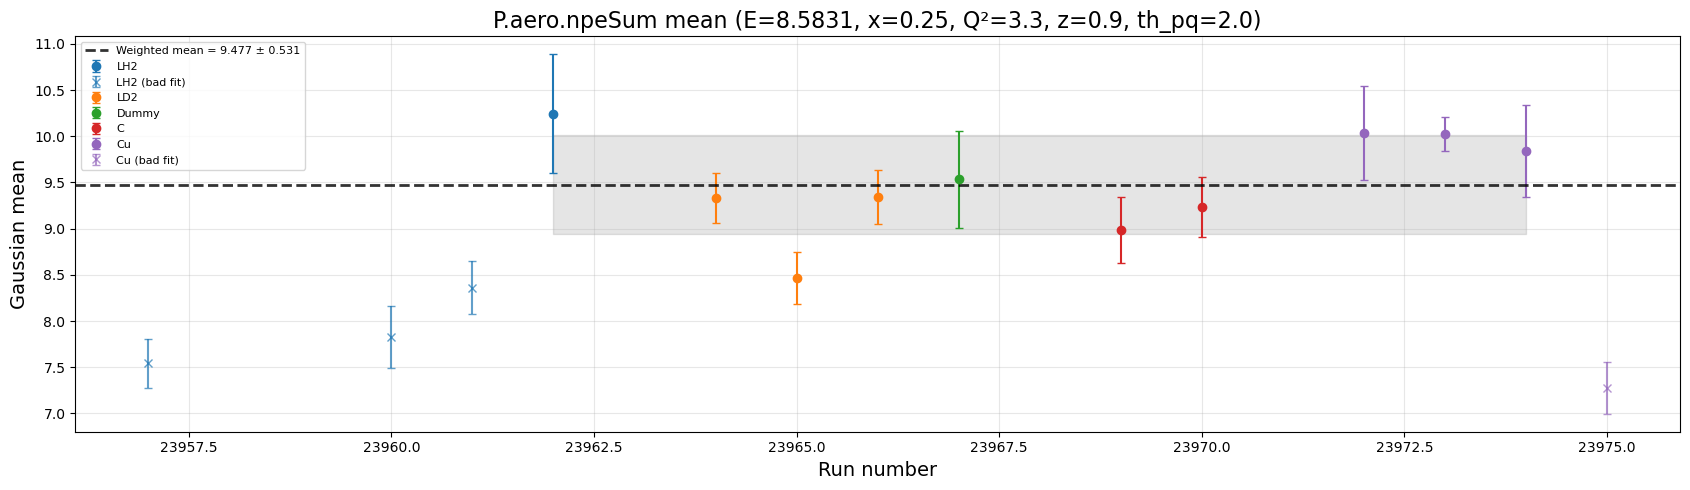

In [41]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.9
thpq = 2.0
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 5:

H.cer Weighted Mean = 8.906 ± 0.171
P.hgcer Weighted Mean = 9.744 ± 0.523
P.aero Weighted Mean = 7.543 ± 0.381


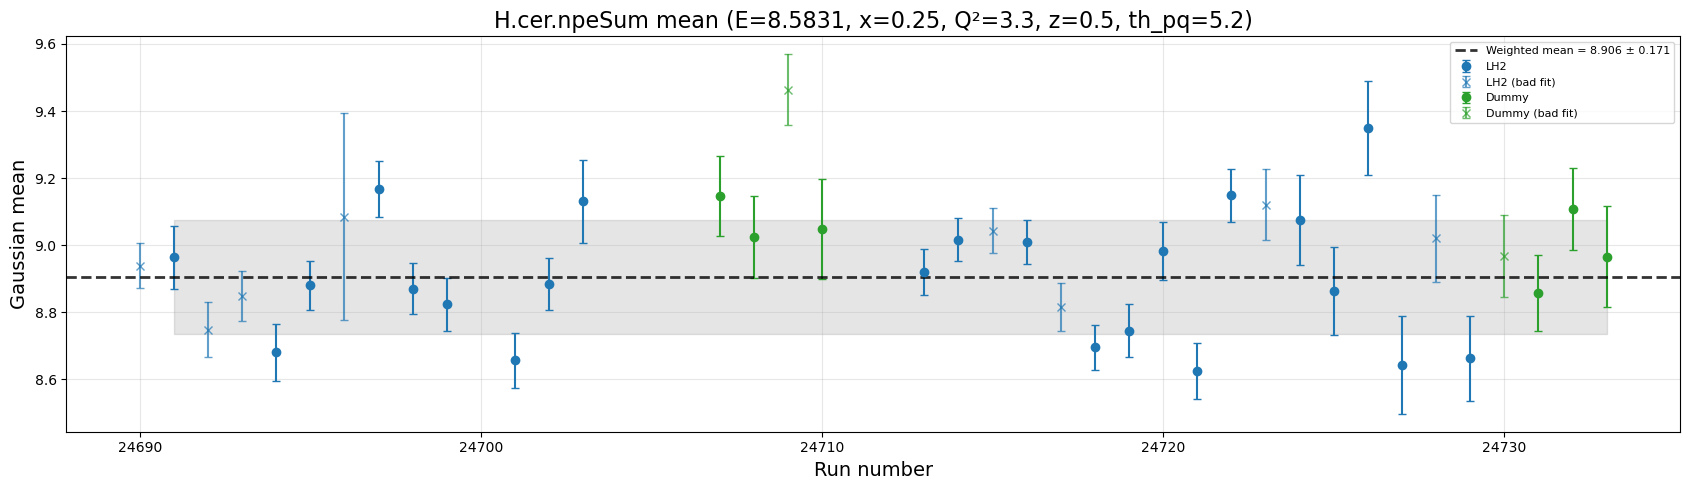

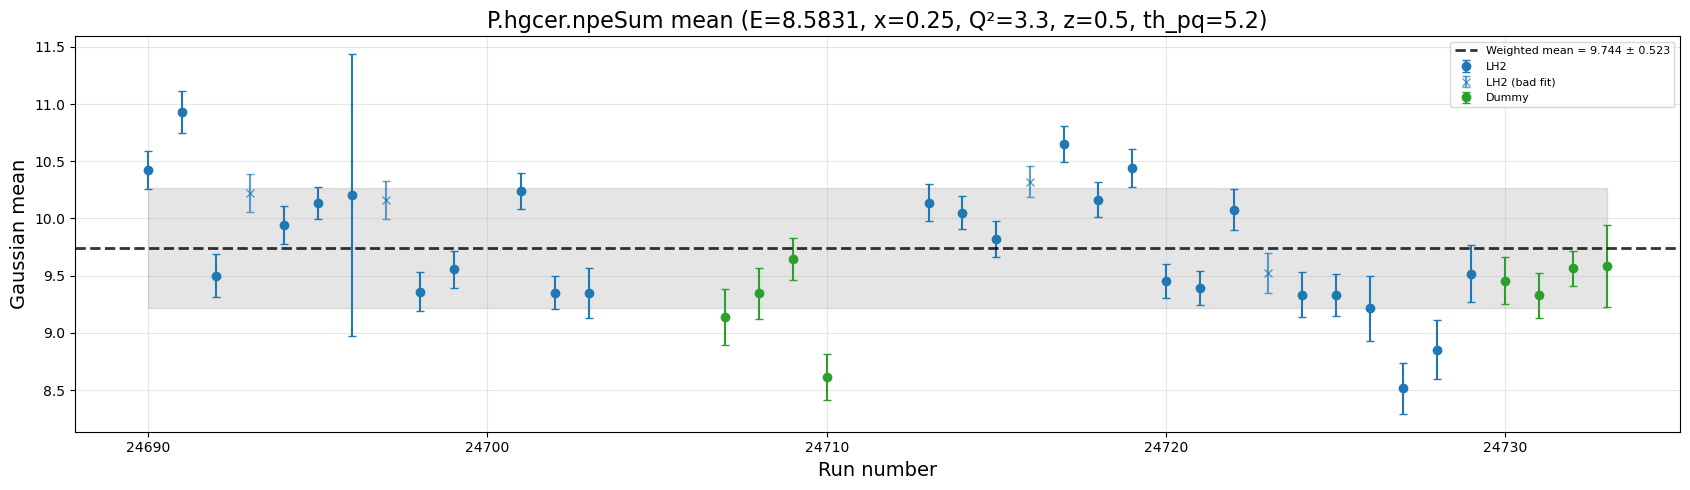

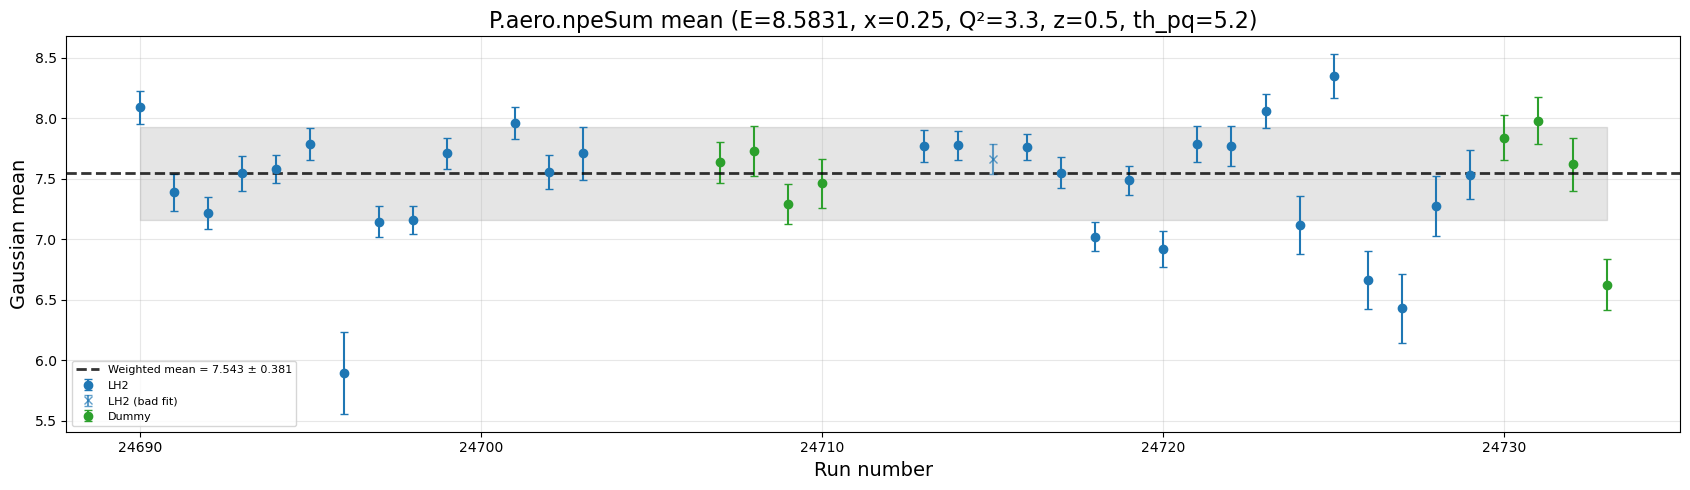

In [44]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 5.2
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["run"] > 23869)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 6

H.cer Weighted Mean = 9.036 ± 0.313
P.hgcer Weighted Mean = 9.275 ± 0.476
P.aero Weighted Mean = 7.496 ± 0.368


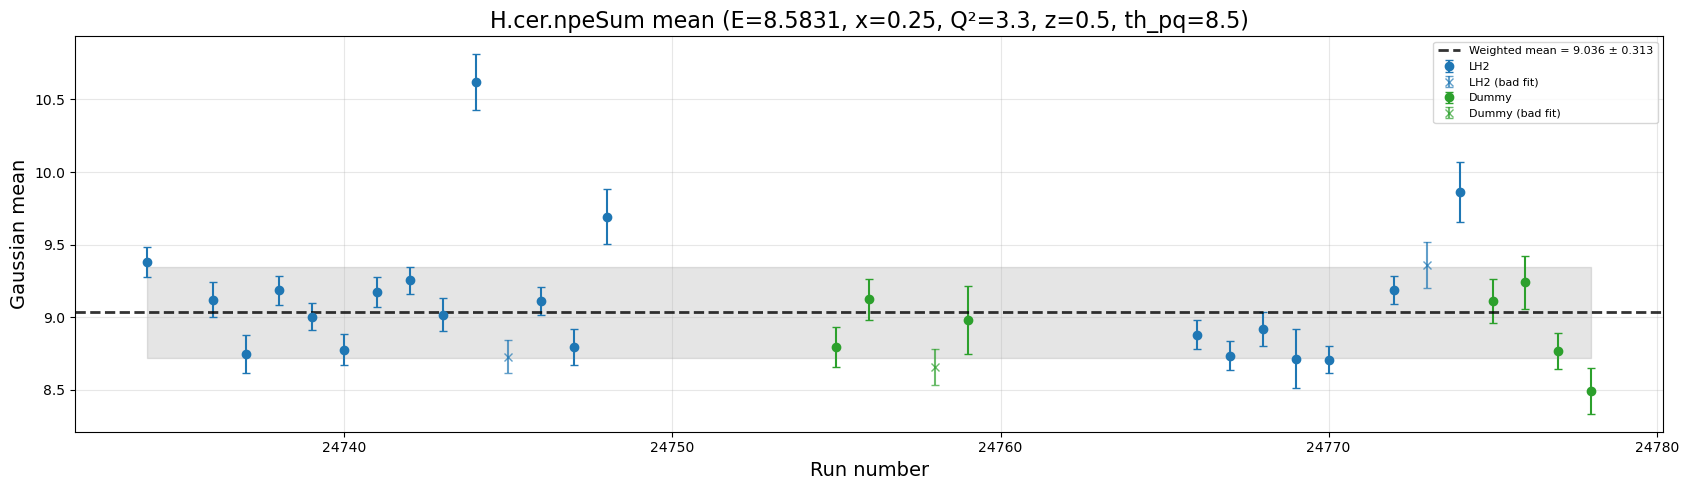

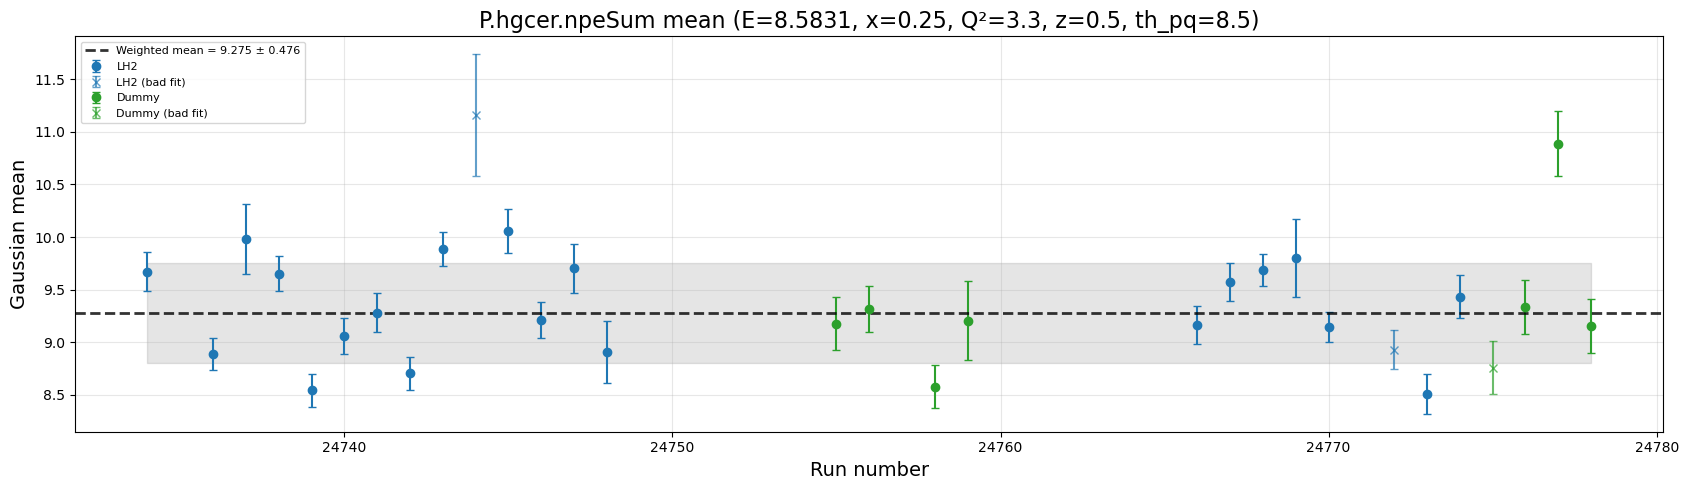

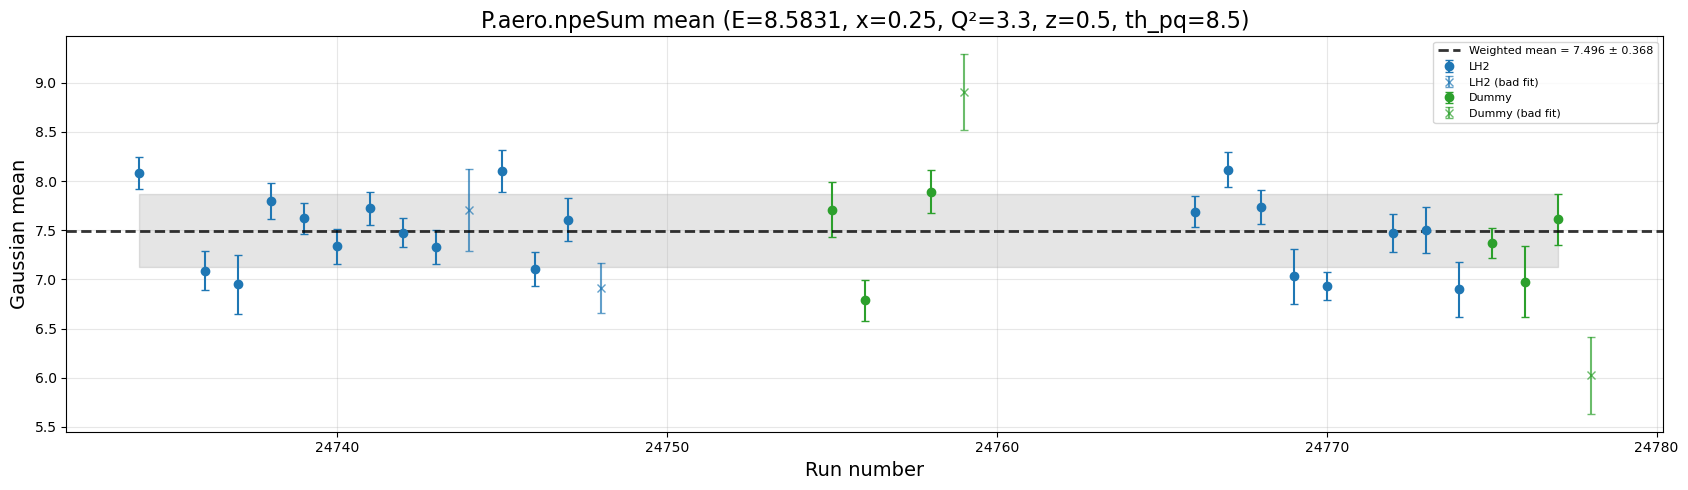

In [45]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 8.5
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### $\pi^+$ Setting 1:

H.cer Weighted Mean = 8.897 ± 0.215
P.hgcer Weighted Mean = 1.796 ± 0.496
P.aero Weighted Mean = 6.827 ± 0.512


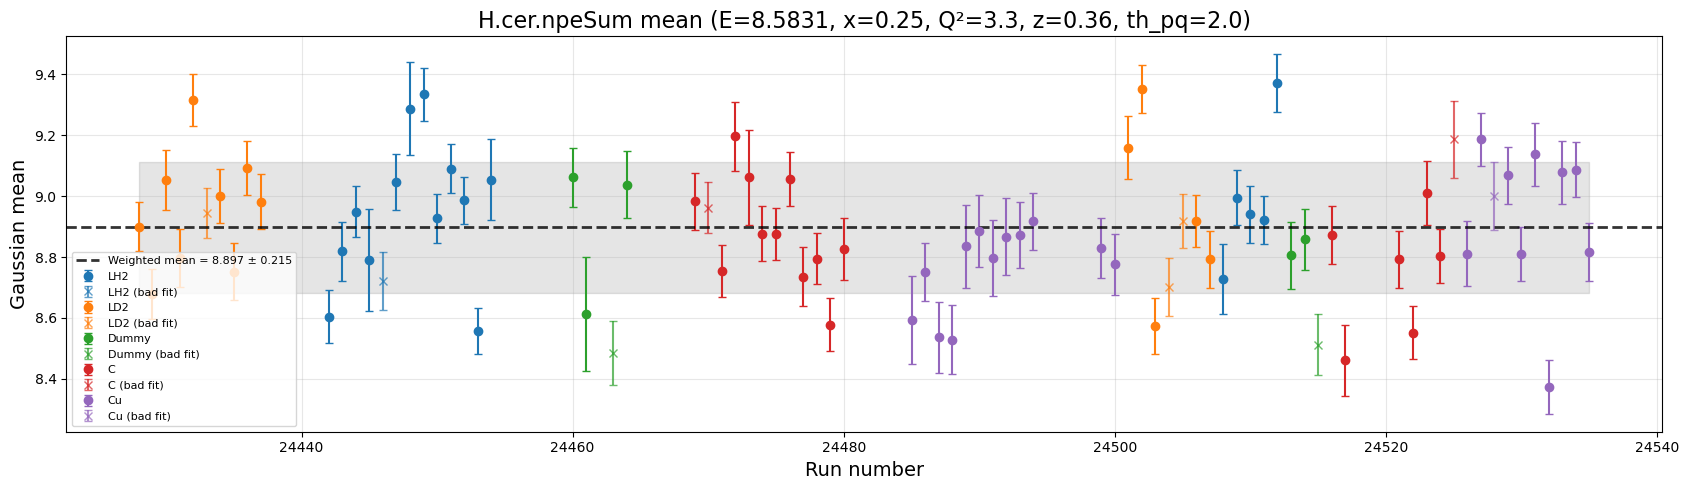

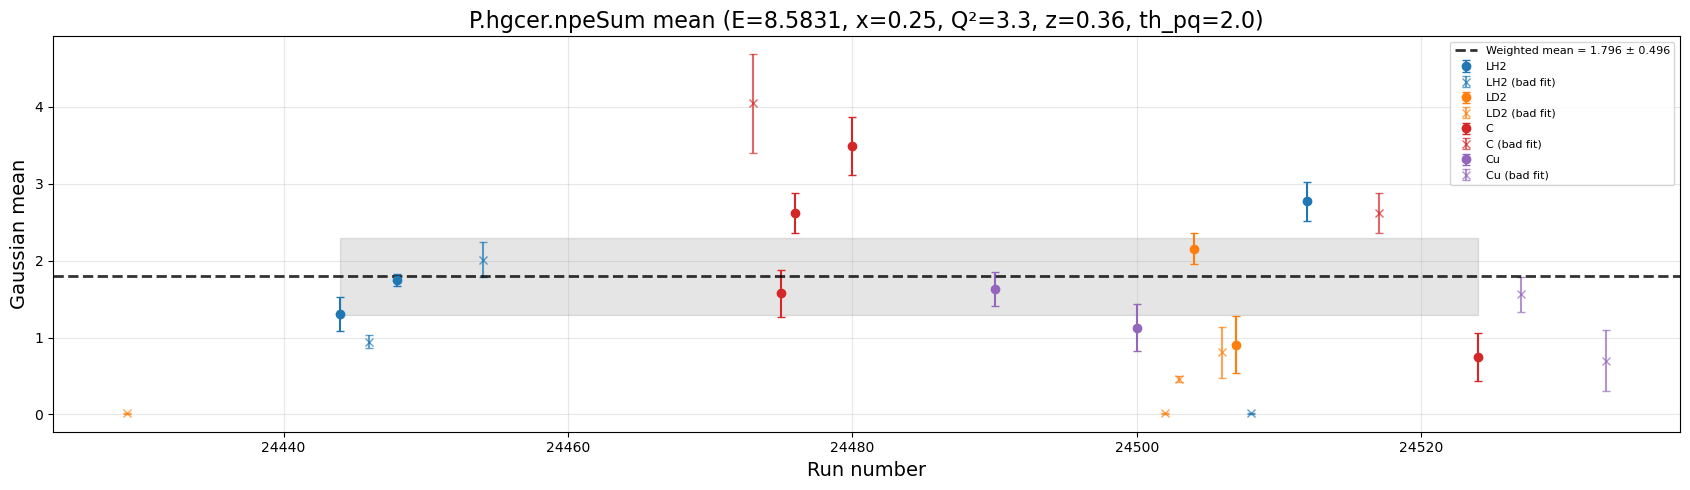

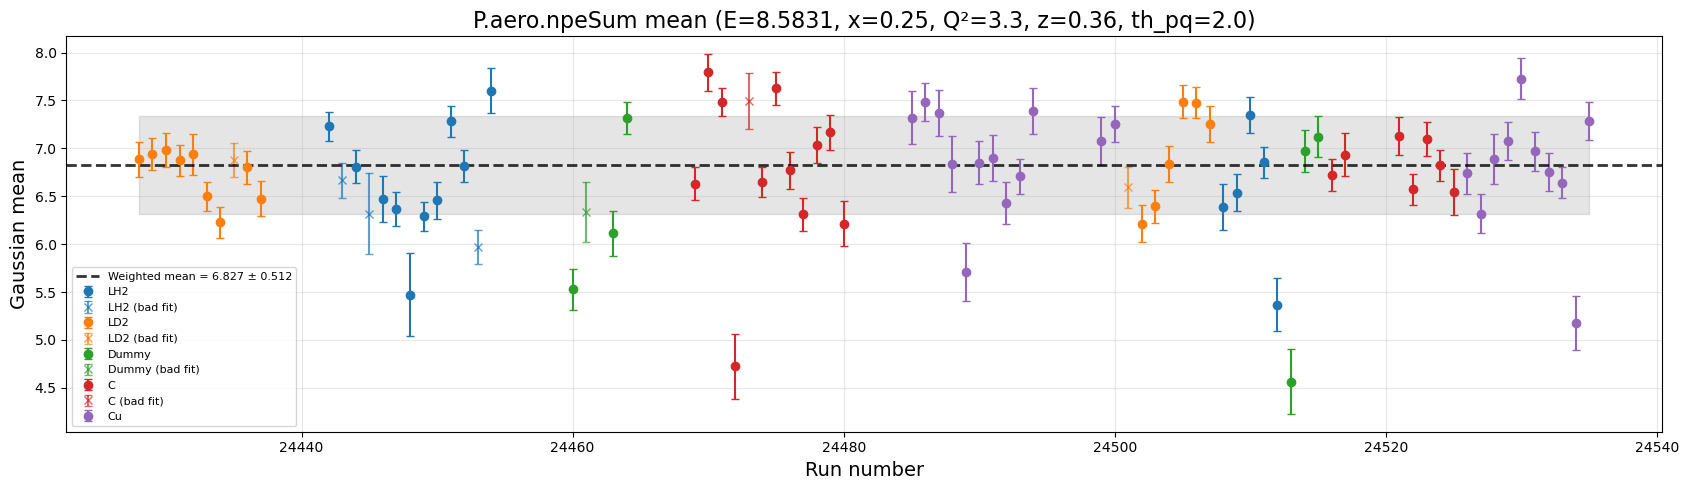

In [46]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.36
thpq = 2.0
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 2:

H.cer Weighted Mean = 8.902 ± 0.168
P.hgcer Weighted Mean = 10.042 ± 0.378
P.aero Weighted Mean = 6.874 ± 0.331


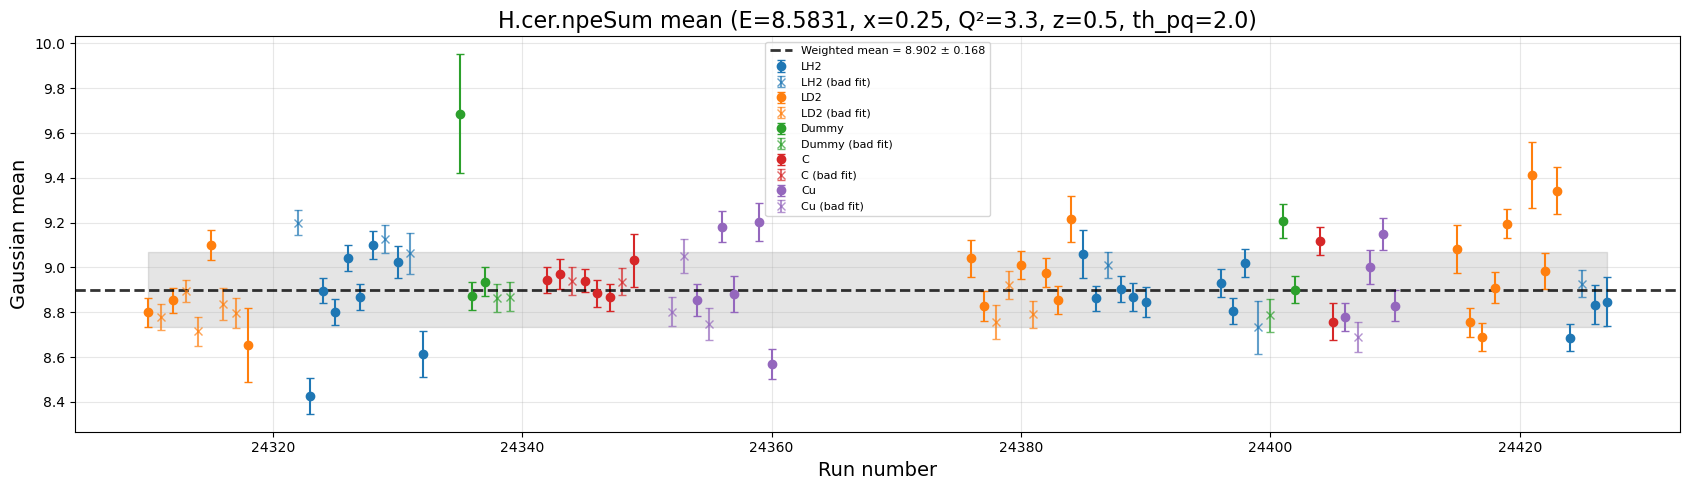

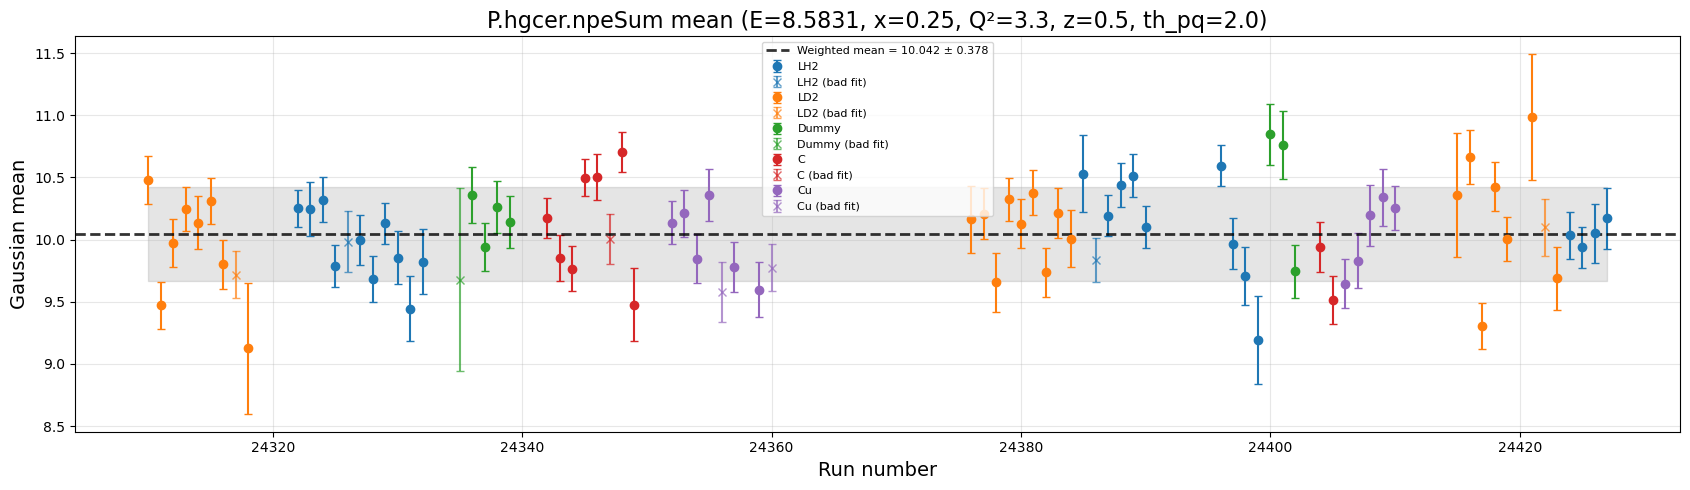

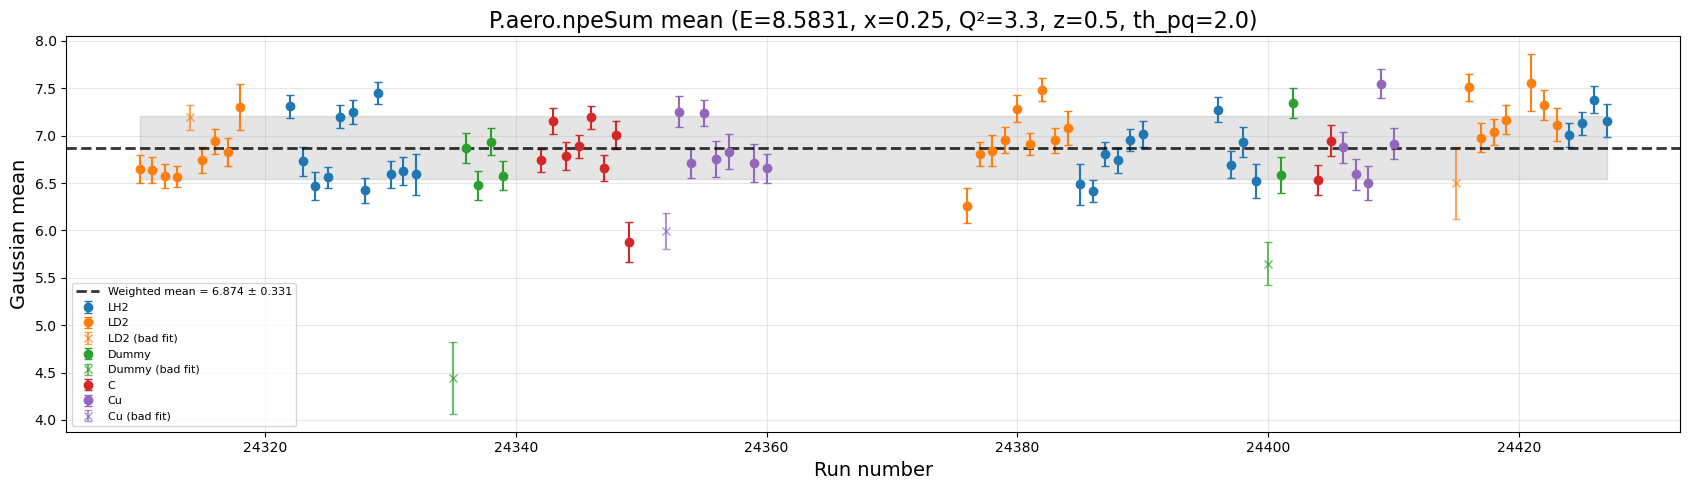

In [47]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 2.0
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 3:

H.cer Weighted Mean = 8.923 ± 0.113
P.hgcer Weighted Mean = 15.429 ± 0.514
P.aero Weighted Mean = 6.441 ± 0.626


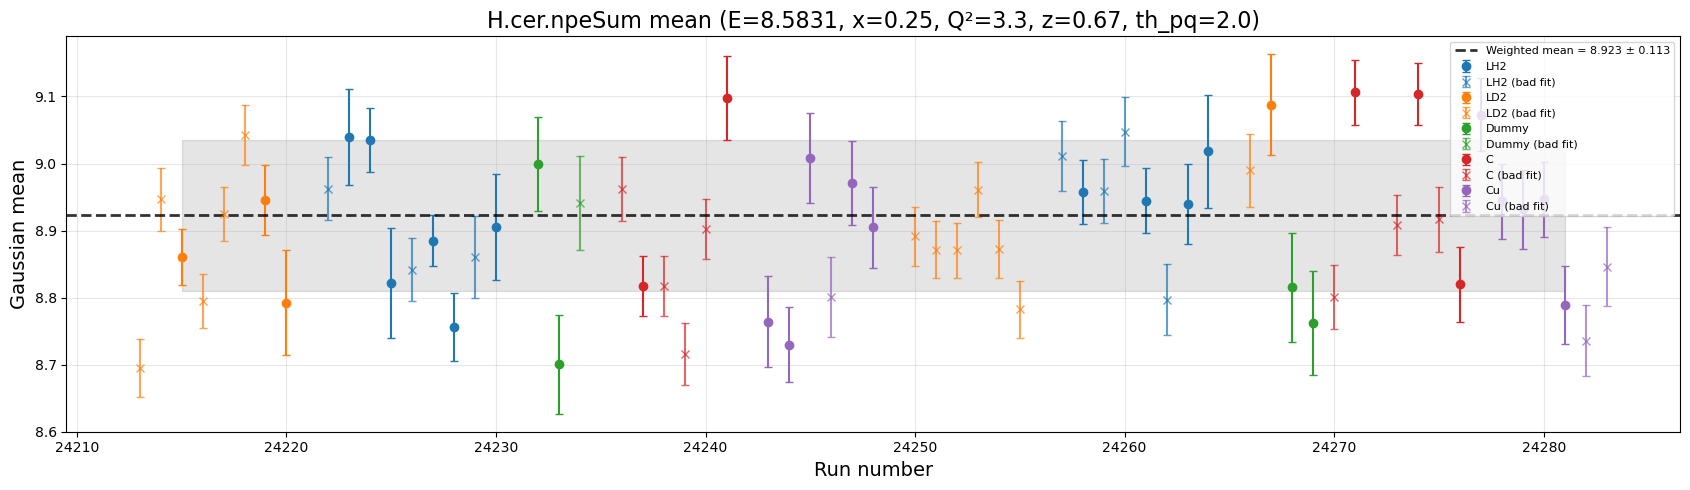

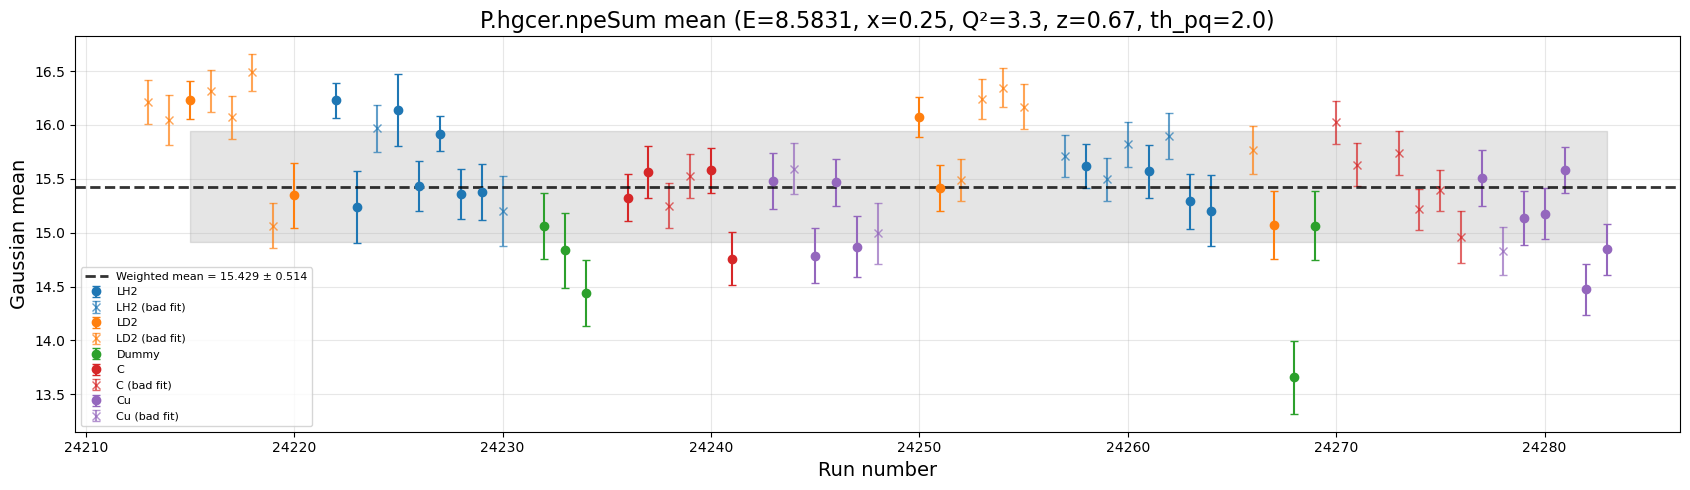

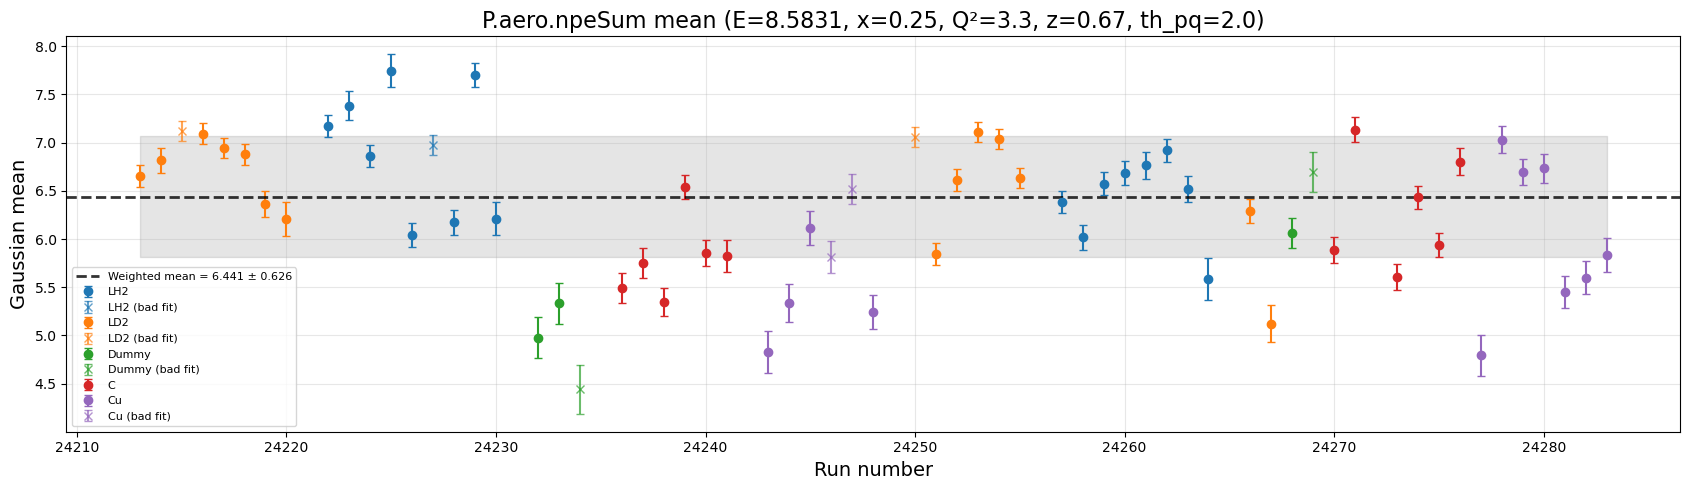

In [48]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.67
thpq = 2.0
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 4:

H.cer Weighted Mean = 8.902 ± 0.185
P.hgcer Weighted Mean = 17.046 ± 0.390
P.aero Weighted Mean = 7.557 ± 0.301


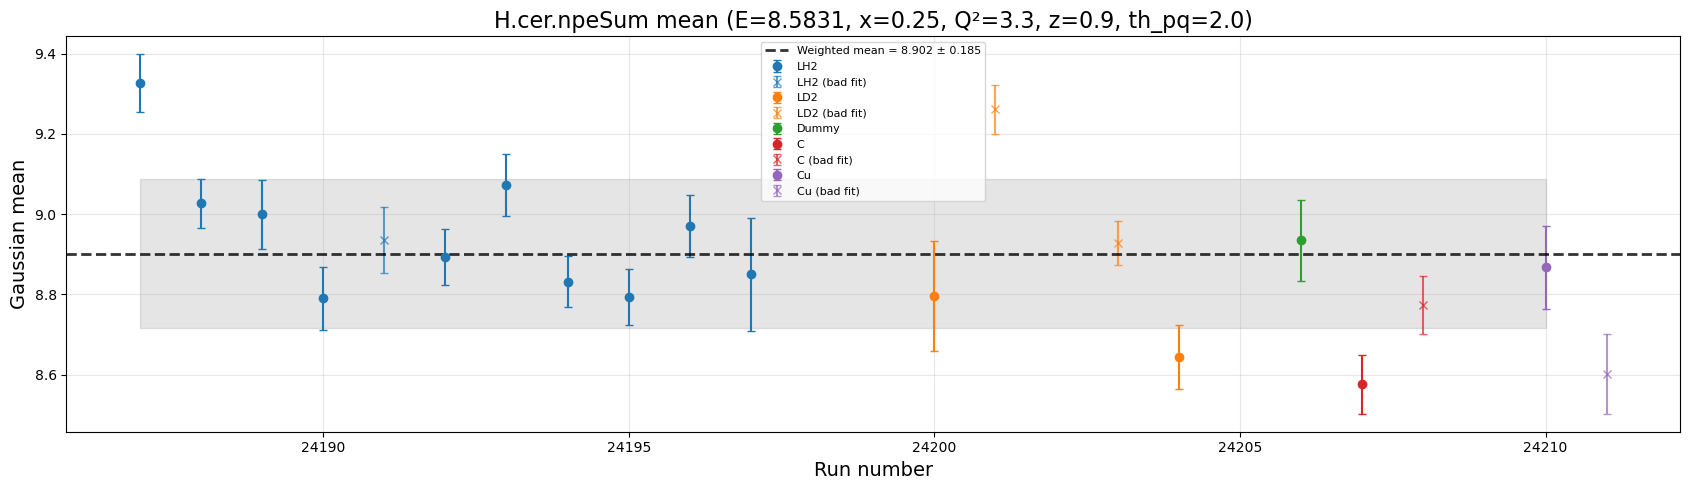

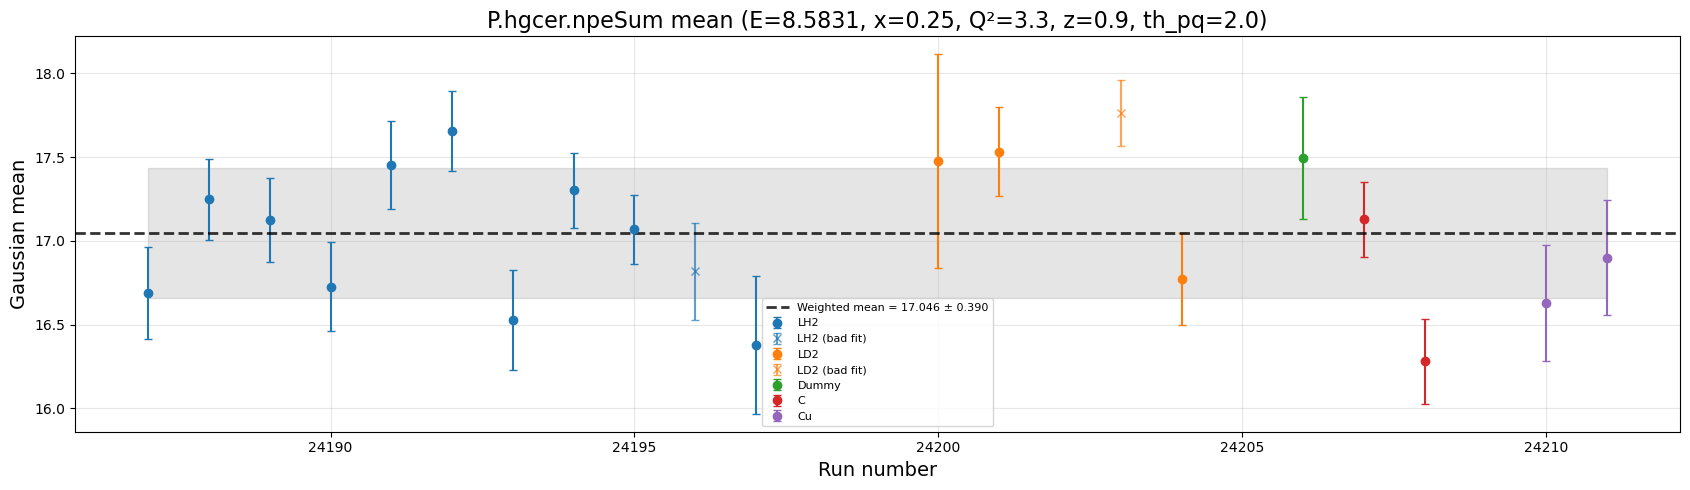

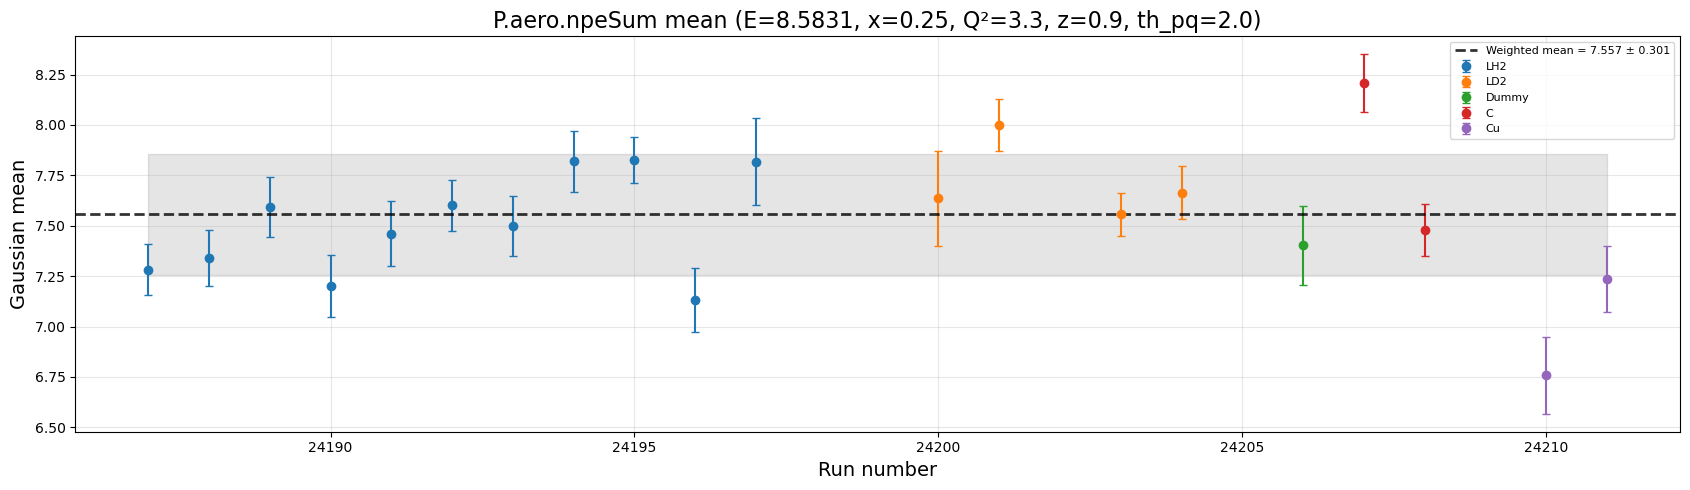

In [49]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.9
thpq = 2.0
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 5:

H.cer Weighted Mean = 8.862 ± 0.185
P.hgcer Weighted Mean = 9.599 ± 0.270
P.aero Weighted Mean = 6.643 ± 0.335


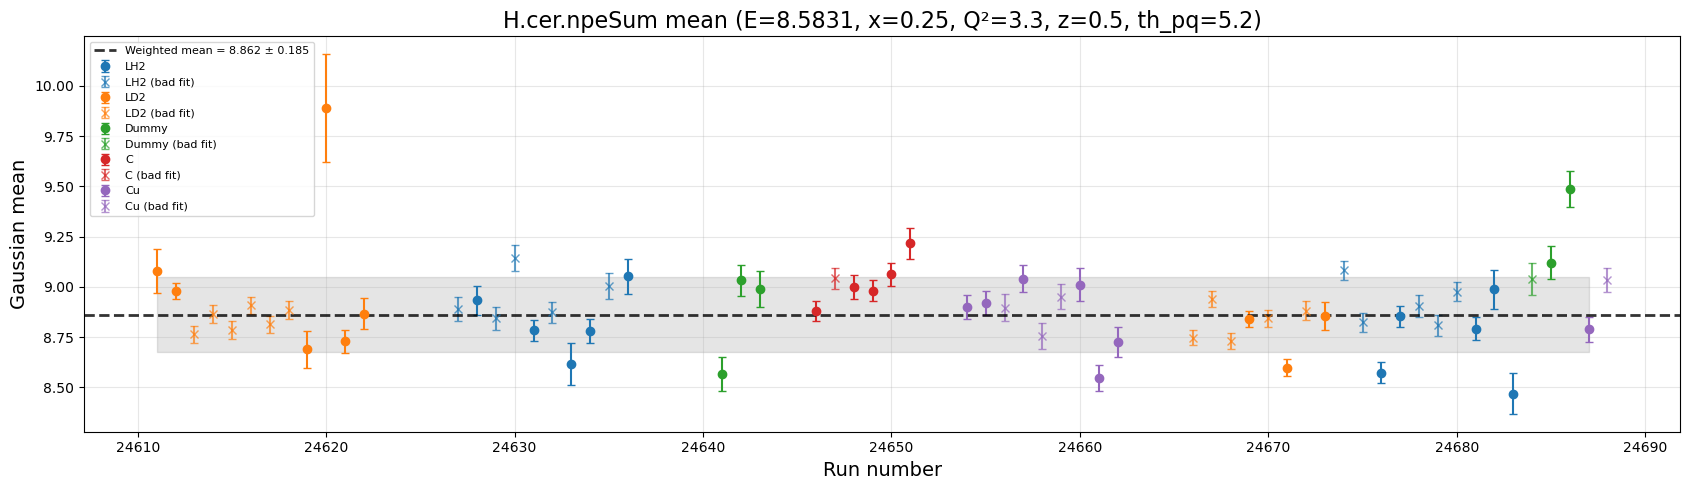

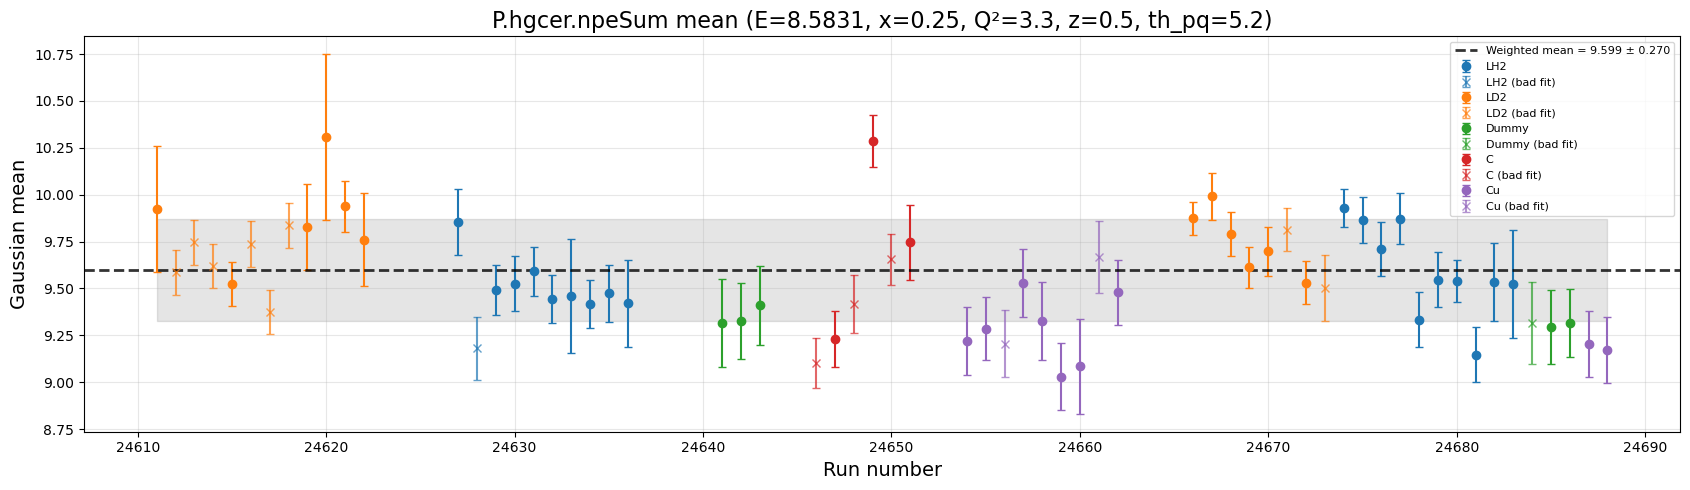

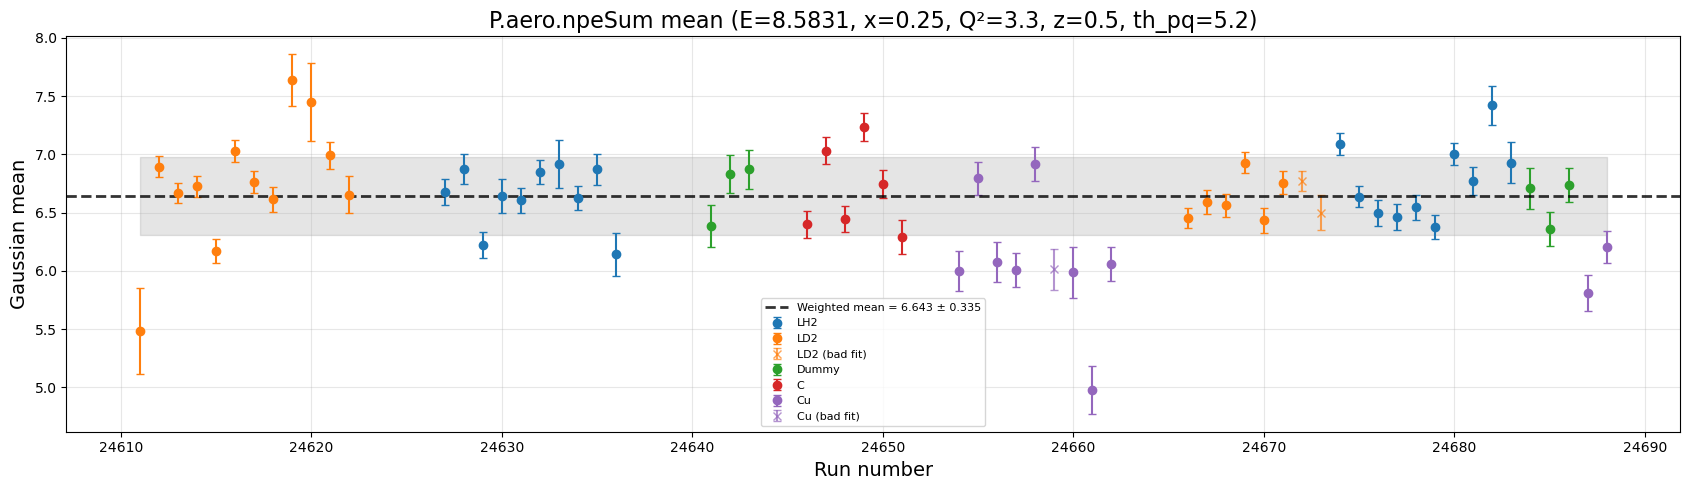

In [50]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 5.2
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 6:

H.cer Weighted Mean = 8.892 ± 0.184
P.hgcer Weighted Mean = 8.989 ± 0.551
P.aero Weighted Mean = 6.242 ± 0.406


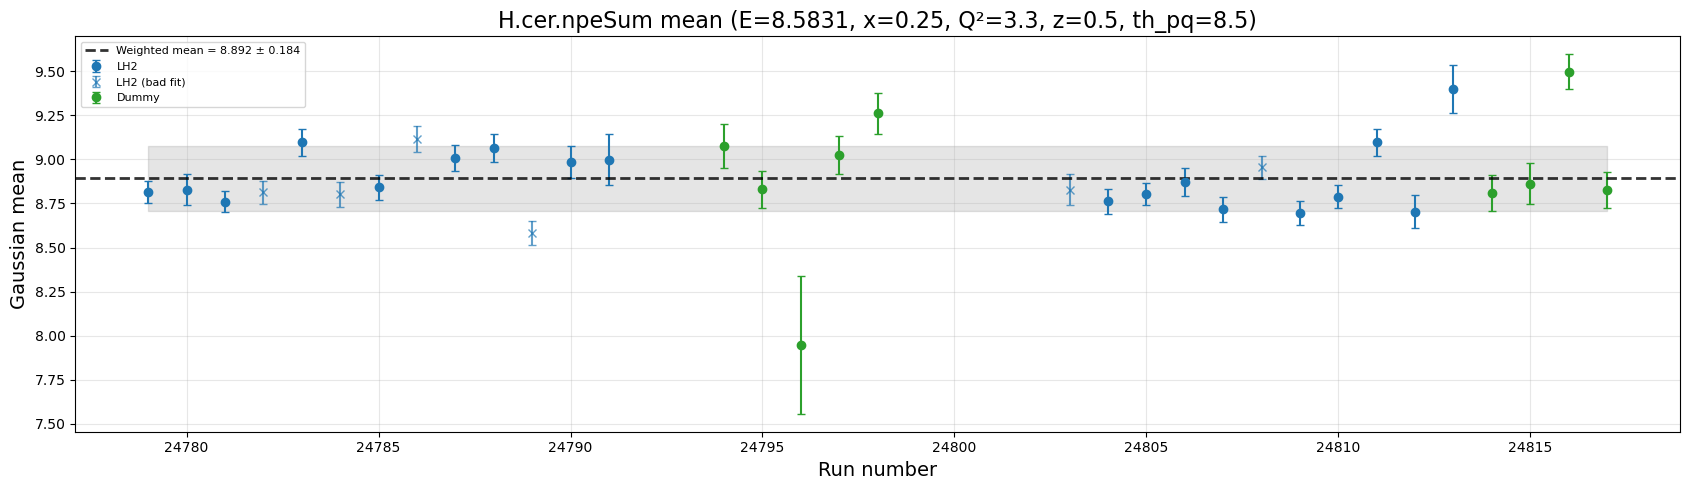

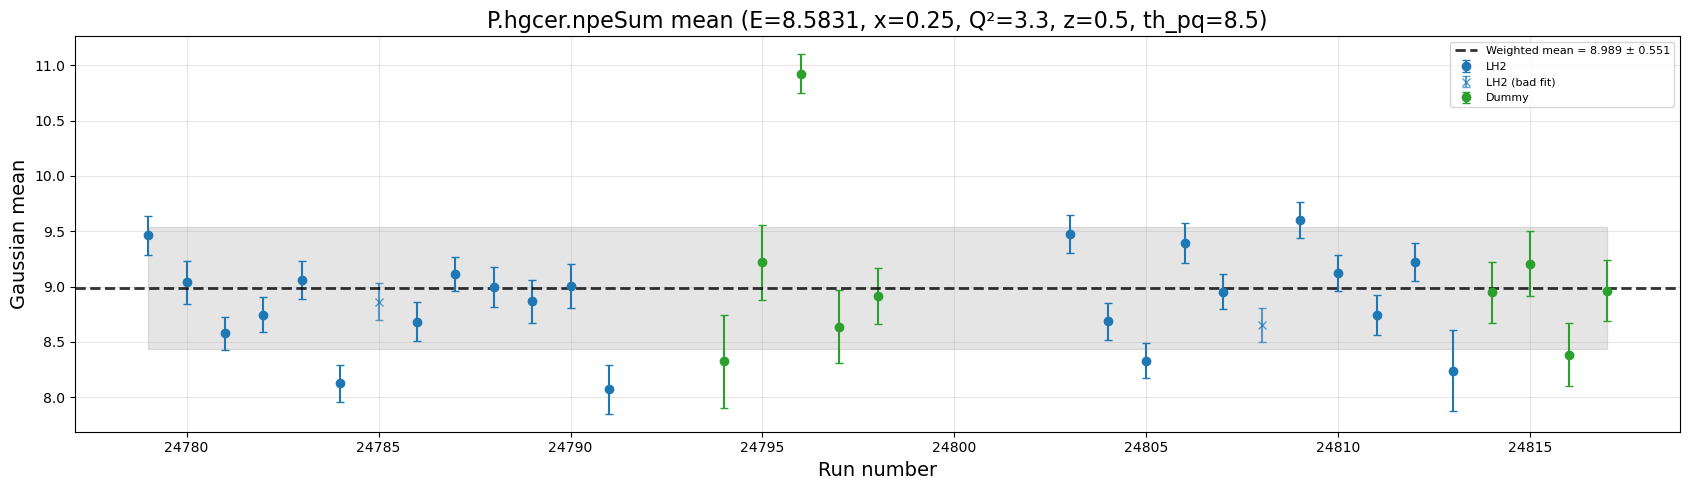

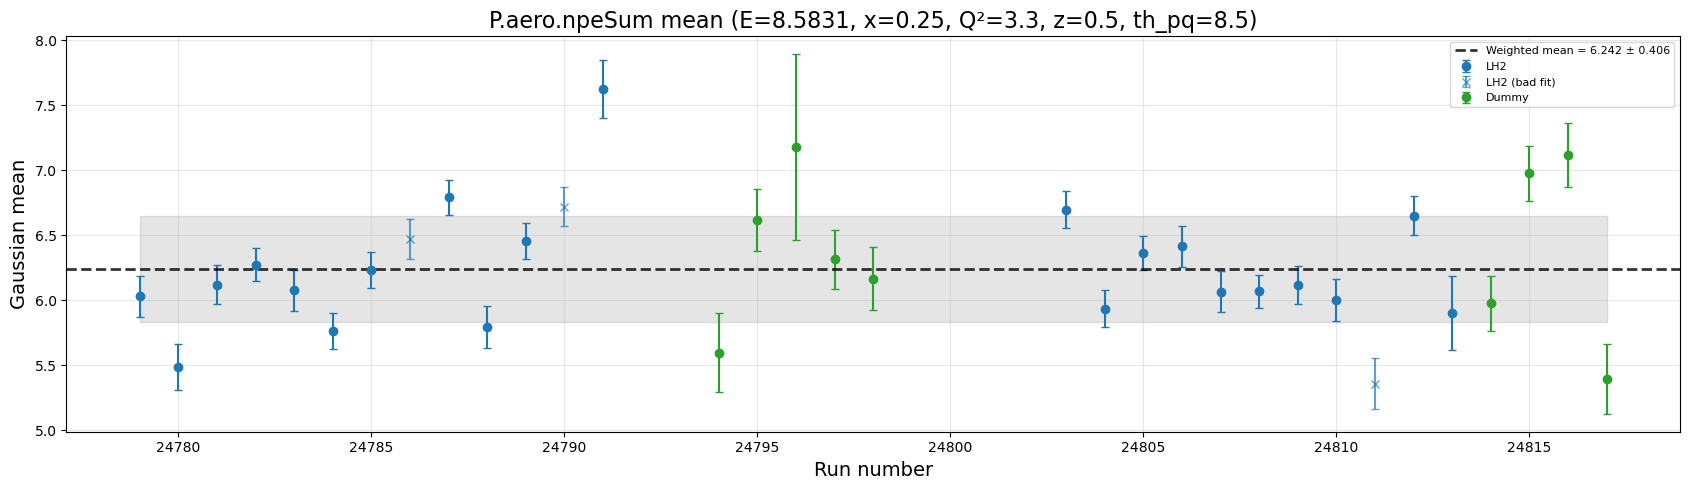

In [51]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 8.5
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



## 5-pass:

### $\pi^-$: Setting 1

H.cer Weighted Mean = 9.058 ± 0.032
P.hgcer Weighted Mean = 9.999 ± 0.384
P.aero Weighted Mean = 7.469 ± 0.237


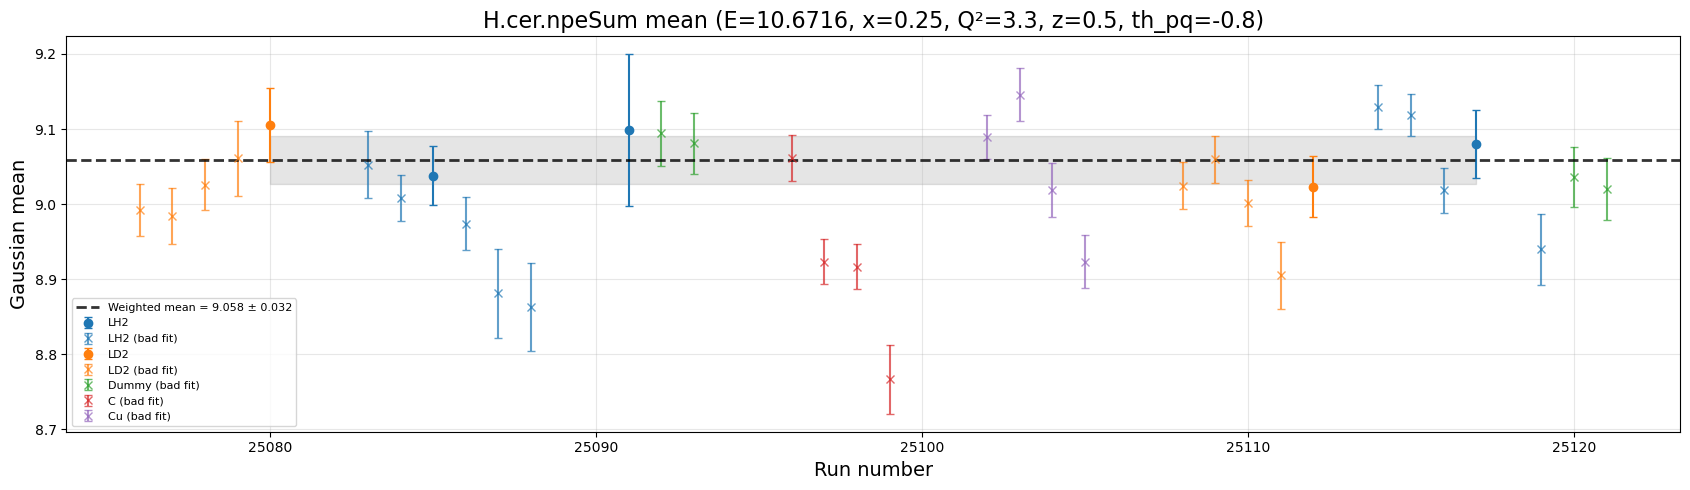

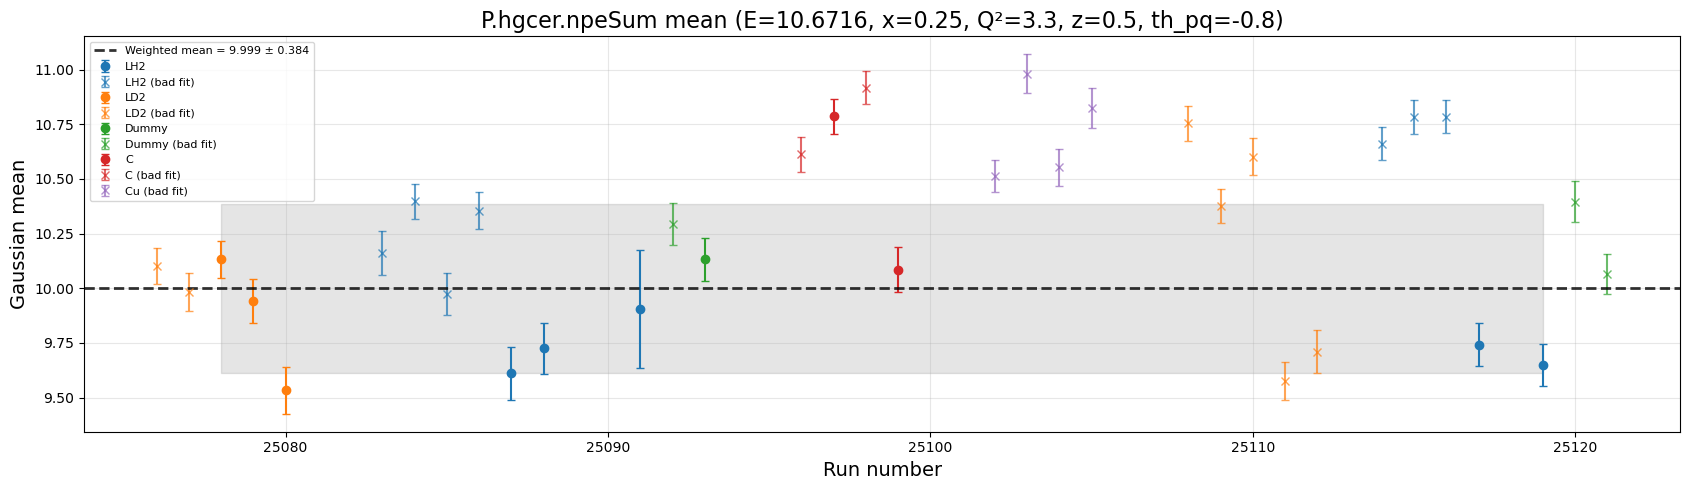

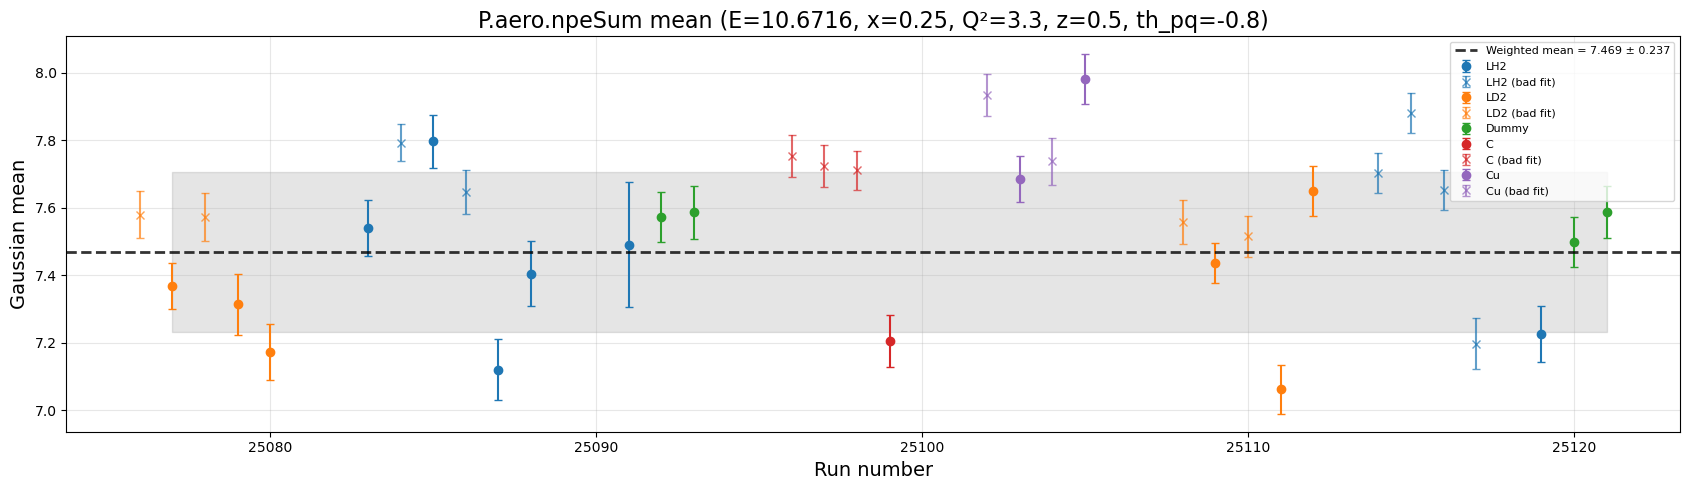

In [54]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.5
thpq = -0.8
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 2:

H.cer Weighted Mean = 9.164 ± 0.000
P.hgcer Weighted Mean = 16.510 ± 0.928
P.aero Weighted Mean = 7.797 ± 0.250


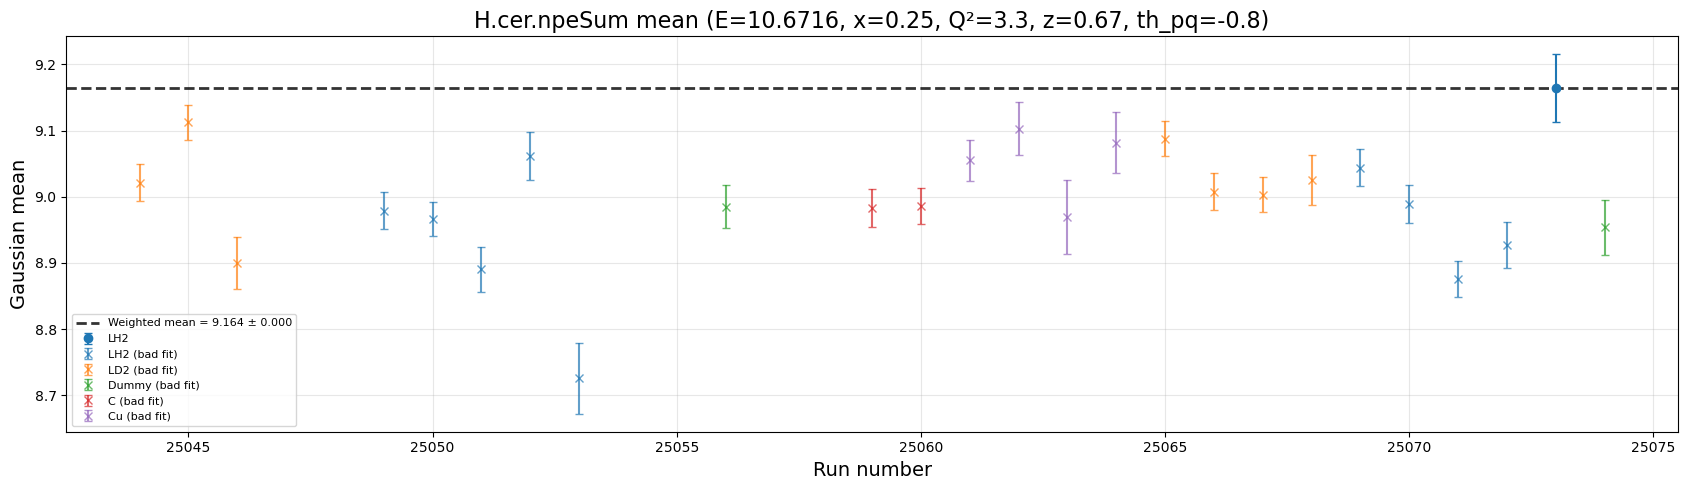

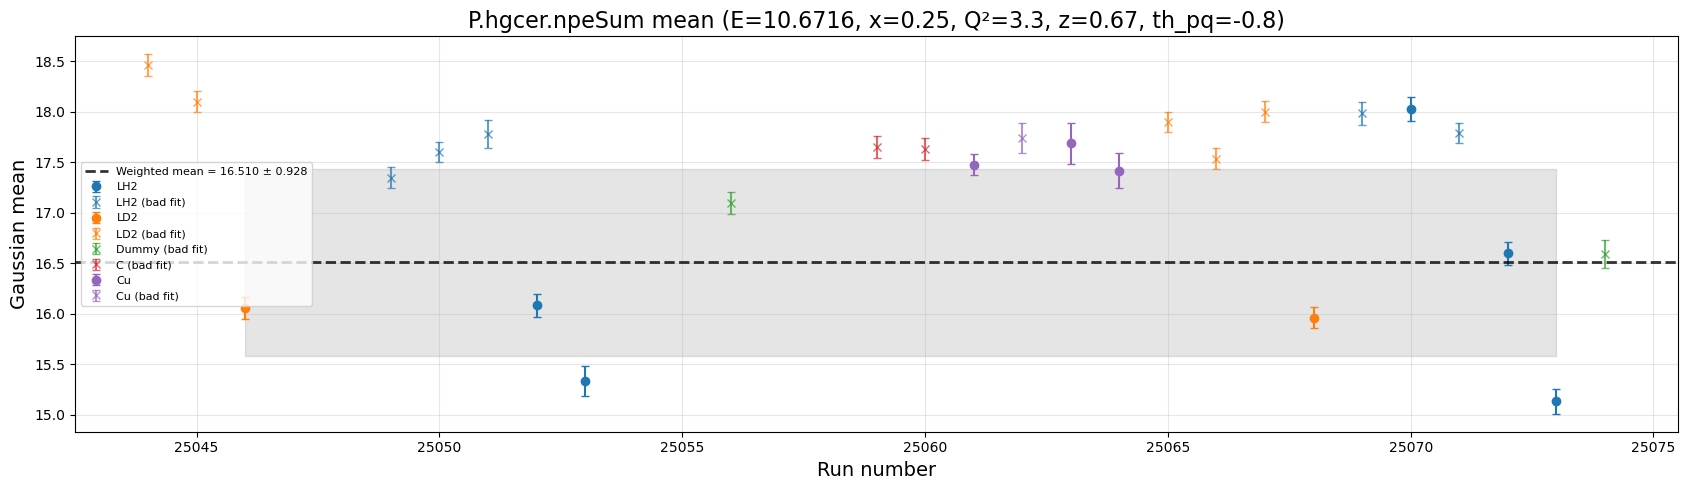

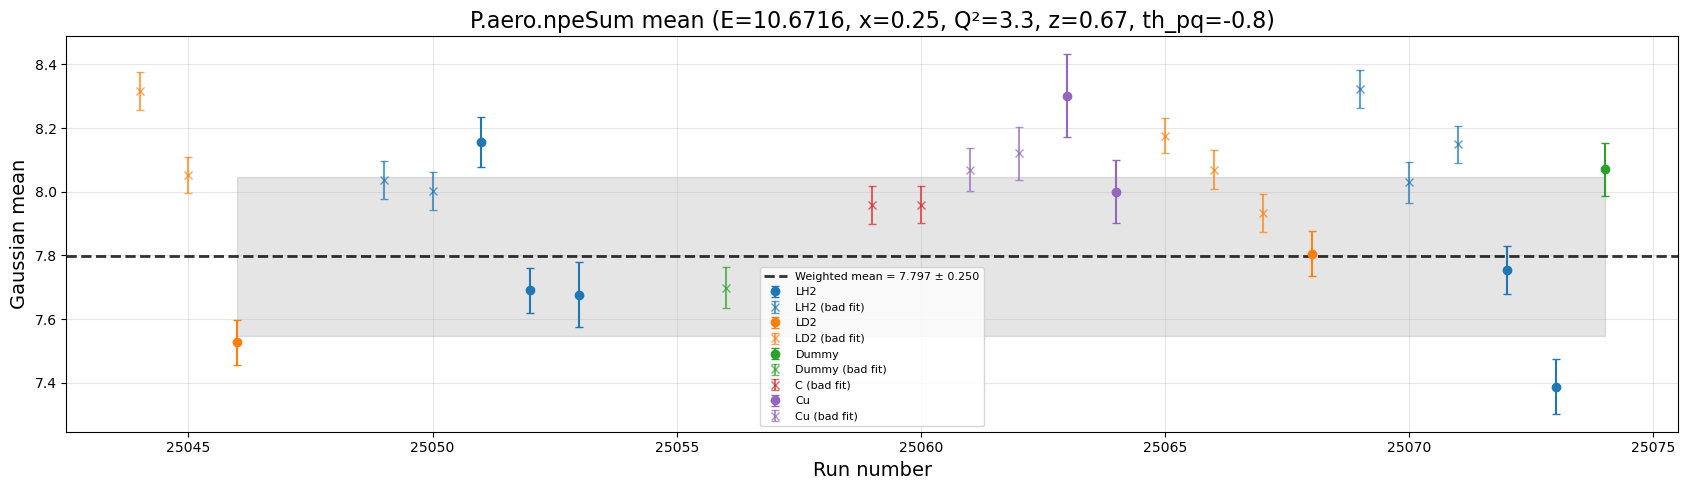

In [55]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.67
thpq = -0.8
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 3

H.cer Weighted Mean = 9.042 ± 0.059
P.hgcer Weighted Mean = 20.283 ± 1.423
P.aero Weighted Mean = 8.314 ± 0.301


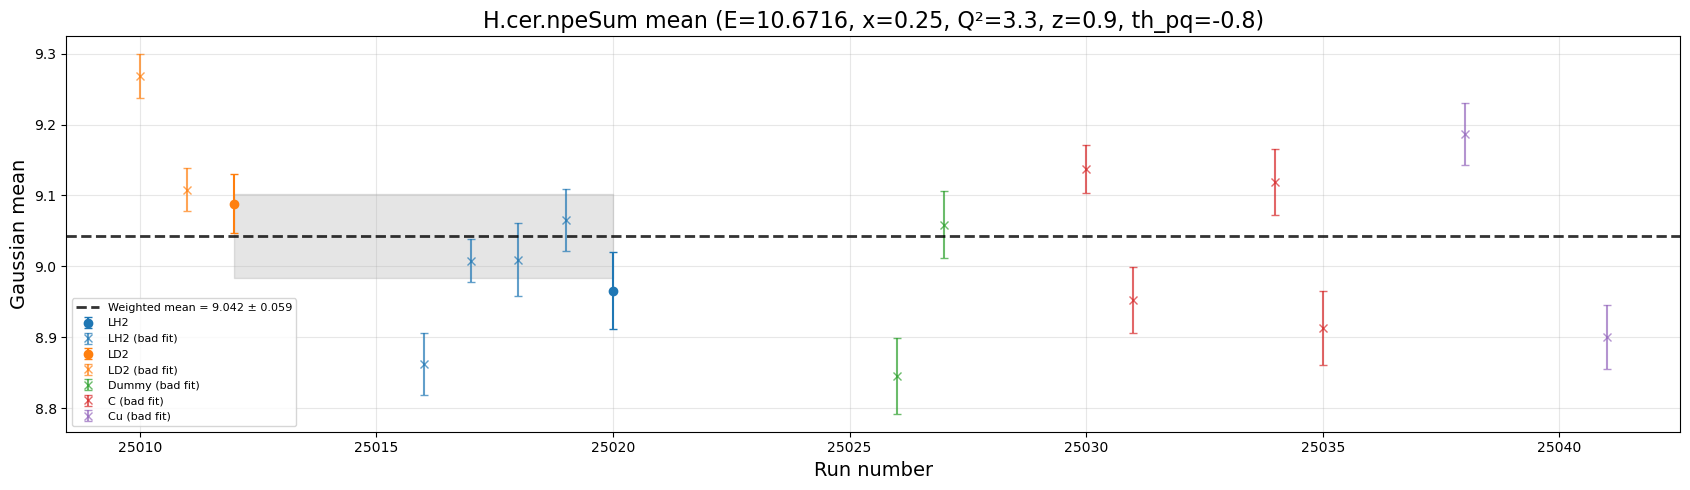

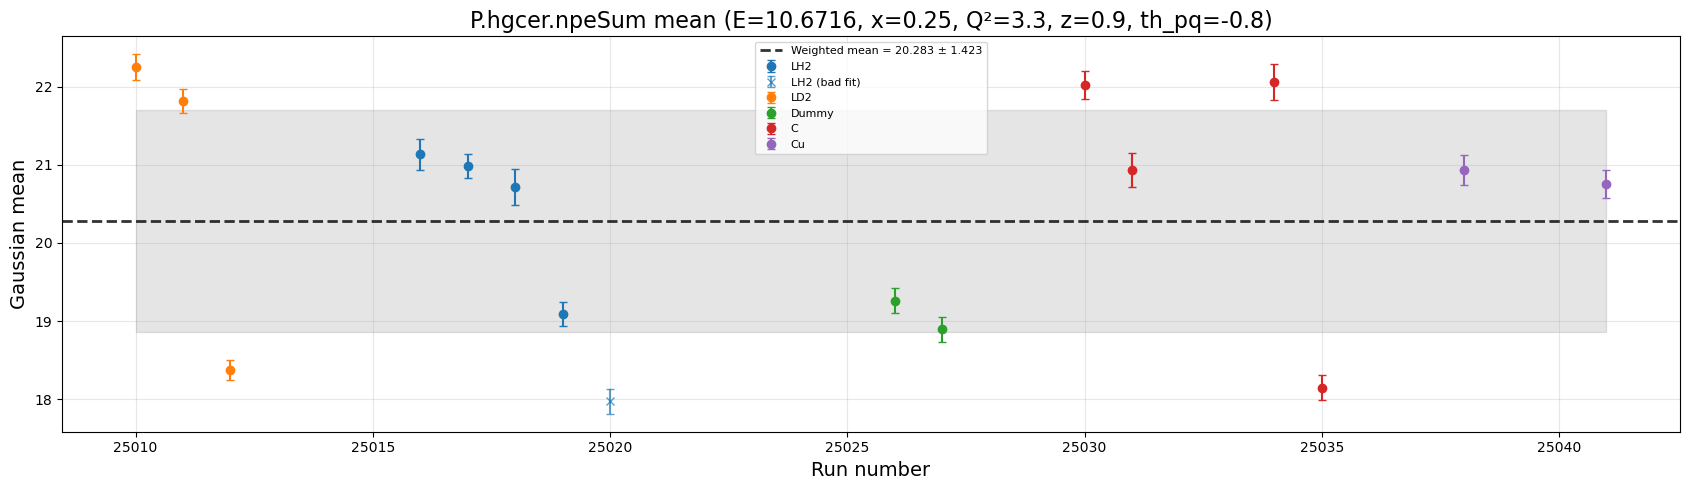

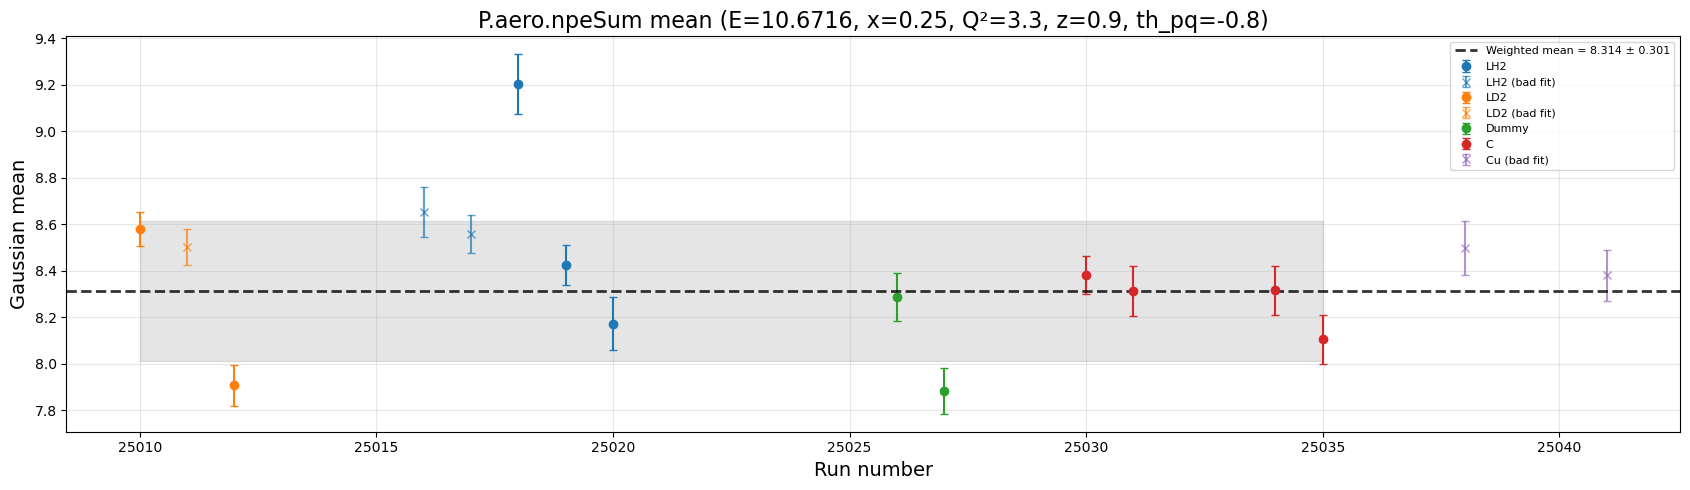

In [57]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.9
thpq = -0.8
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 4

H.cer Weighted Mean = 9.012 ± 0.000
P.hgcer: No valid GOOD runs for weighted mean.
P.aero Weighted Mean = 7.212 ± 0.174


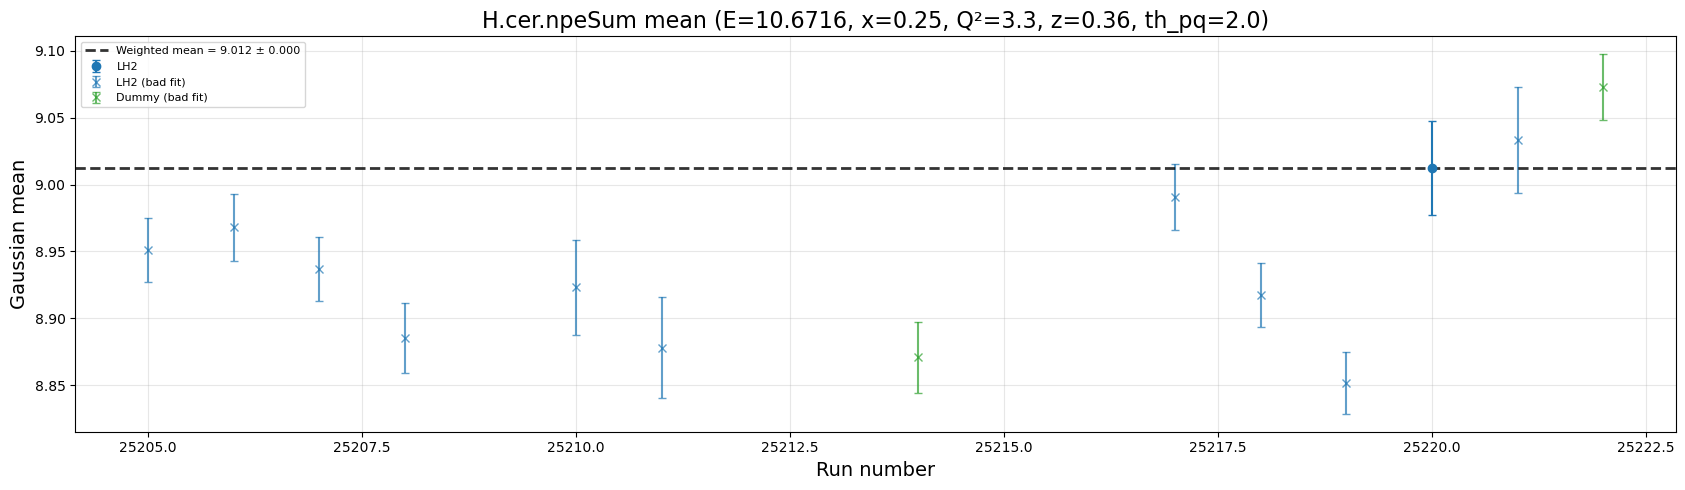

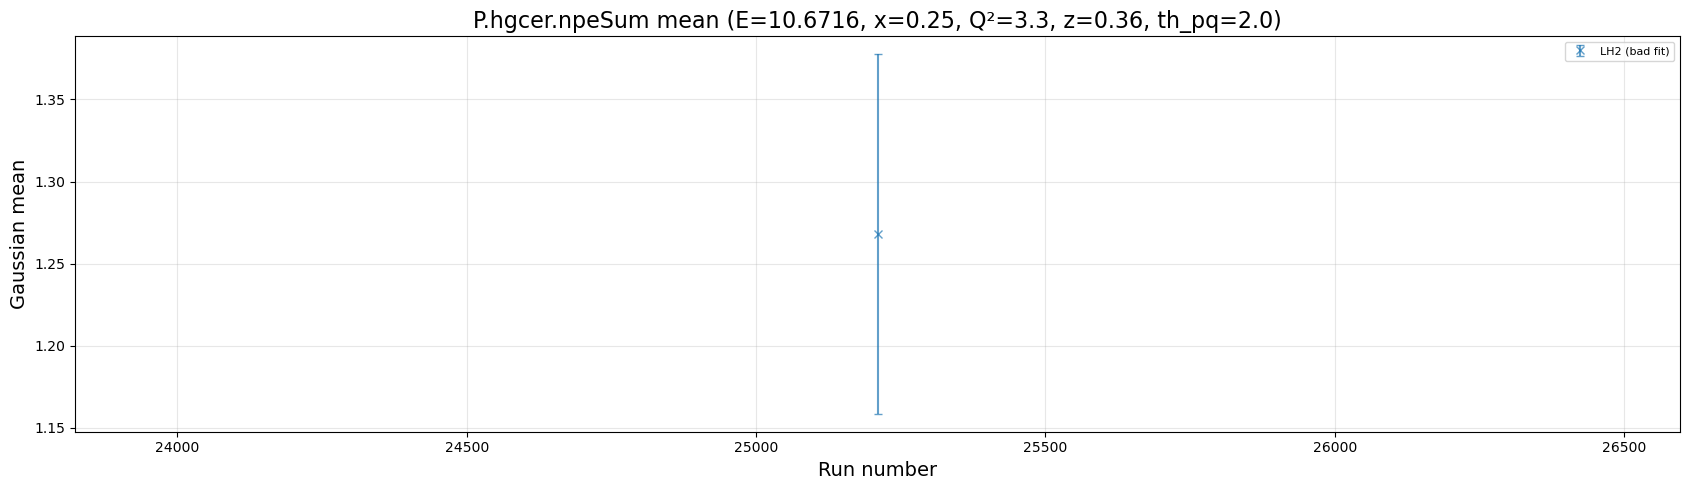

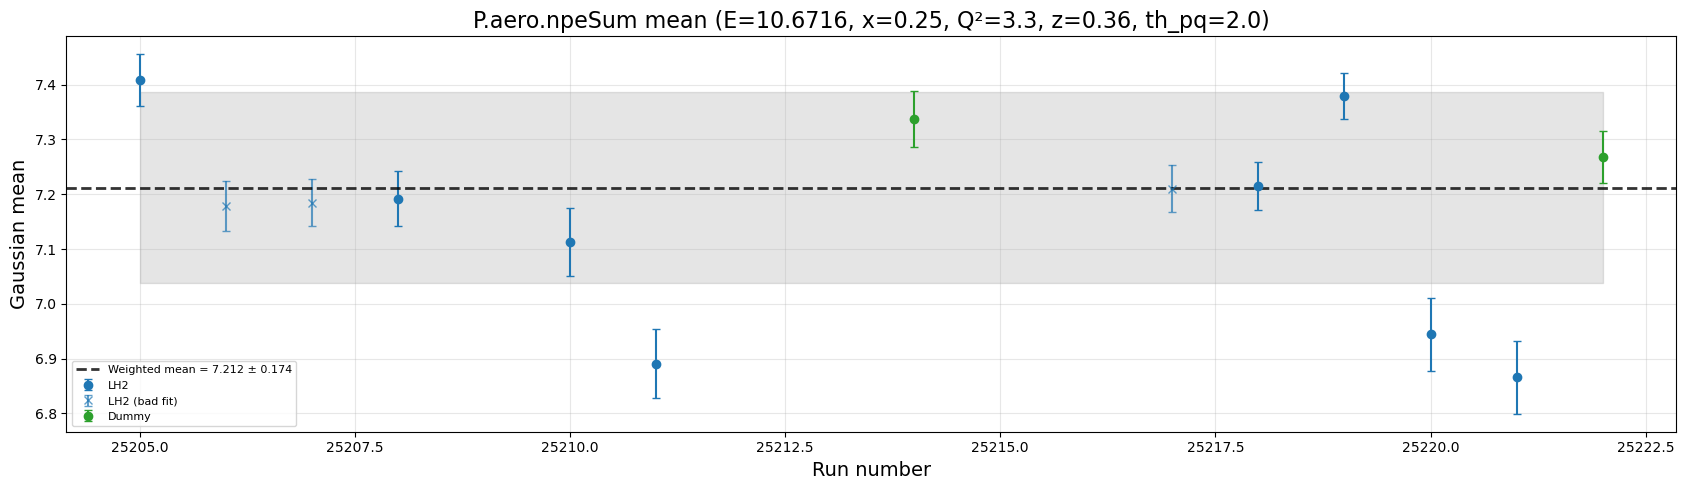

In [60]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.36
thpq = 2.0
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.3 < chi2ndf < 3.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

### Setting 5

H.cer Weighted Mean = 8.881 ± 0.035
P.hgcer Weighted Mean = 9.662 ± 0.280
P.aero Weighted Mean = 7.453 ± 0.165


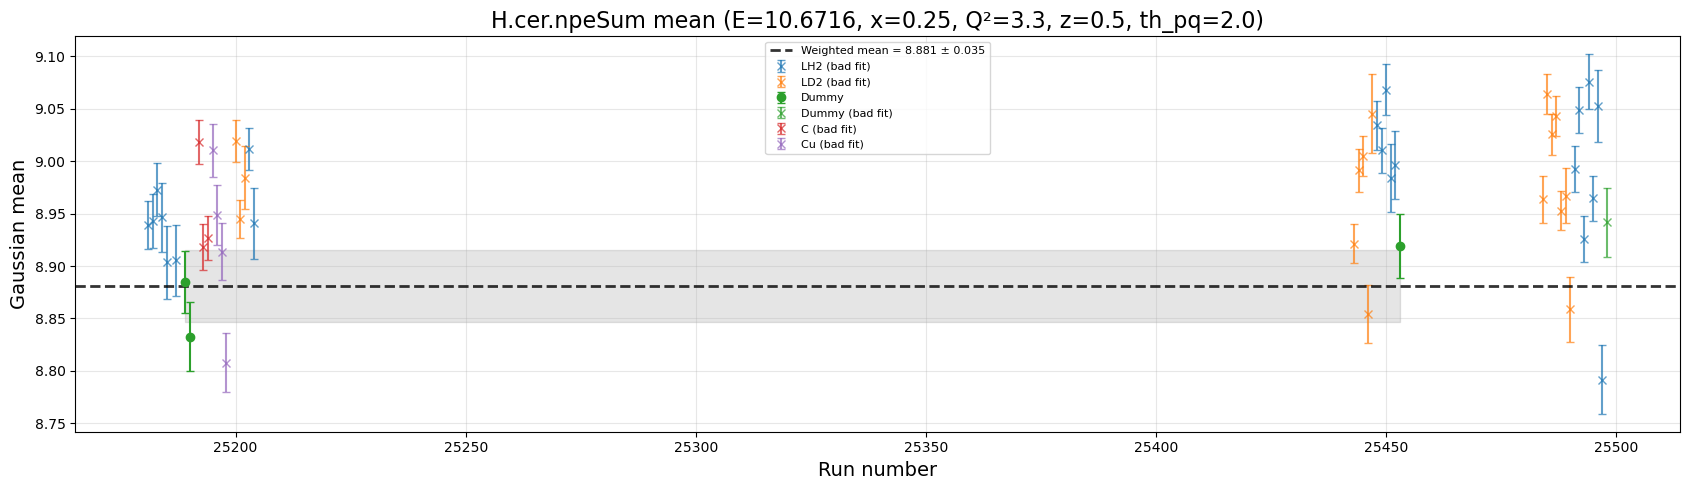

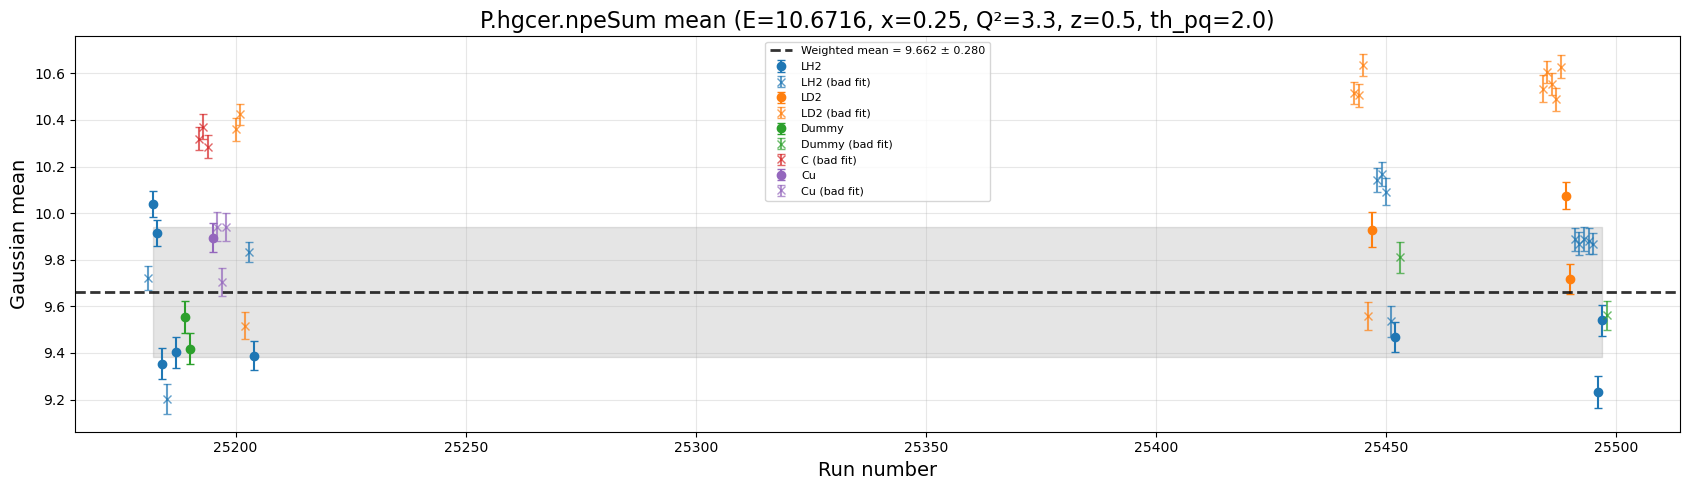

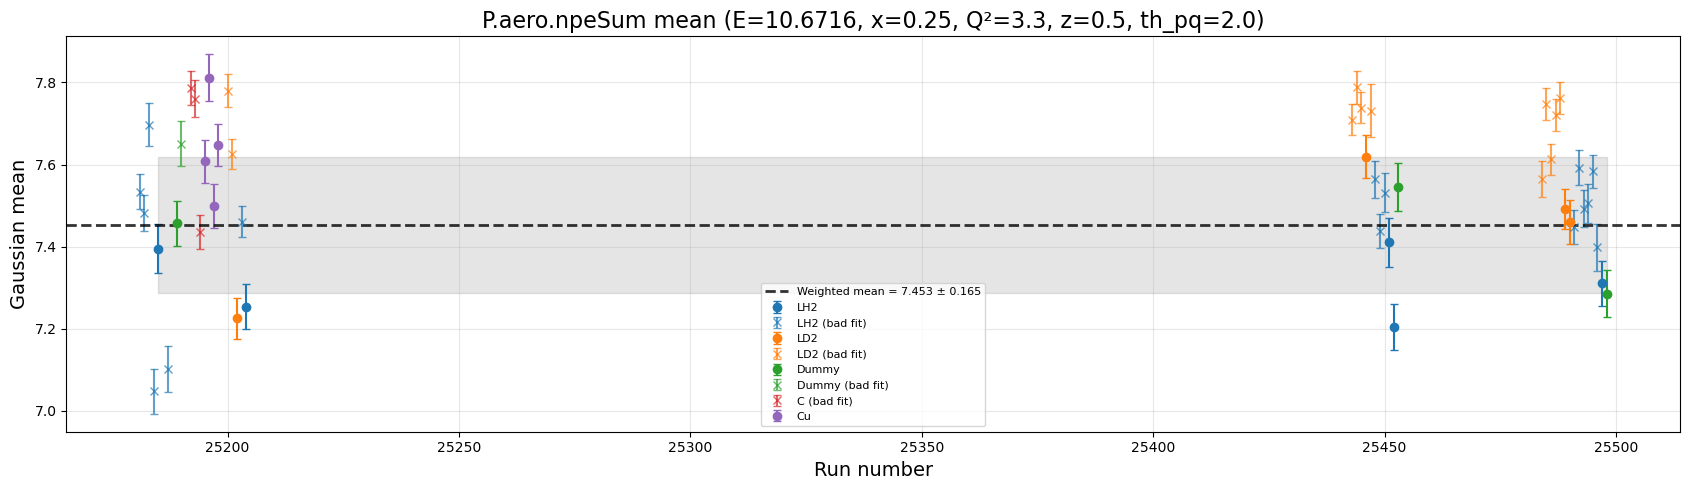

In [63]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 2.0
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.3 < chi2ndf < 3.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

### Setting 6:

H.cer Weighted Mean = 8.990 ± 0.123
P.hgcer Weighted Mean = 14.584 ± 0.221
P.aero Weighted Mean = 7.541 ± 0.136


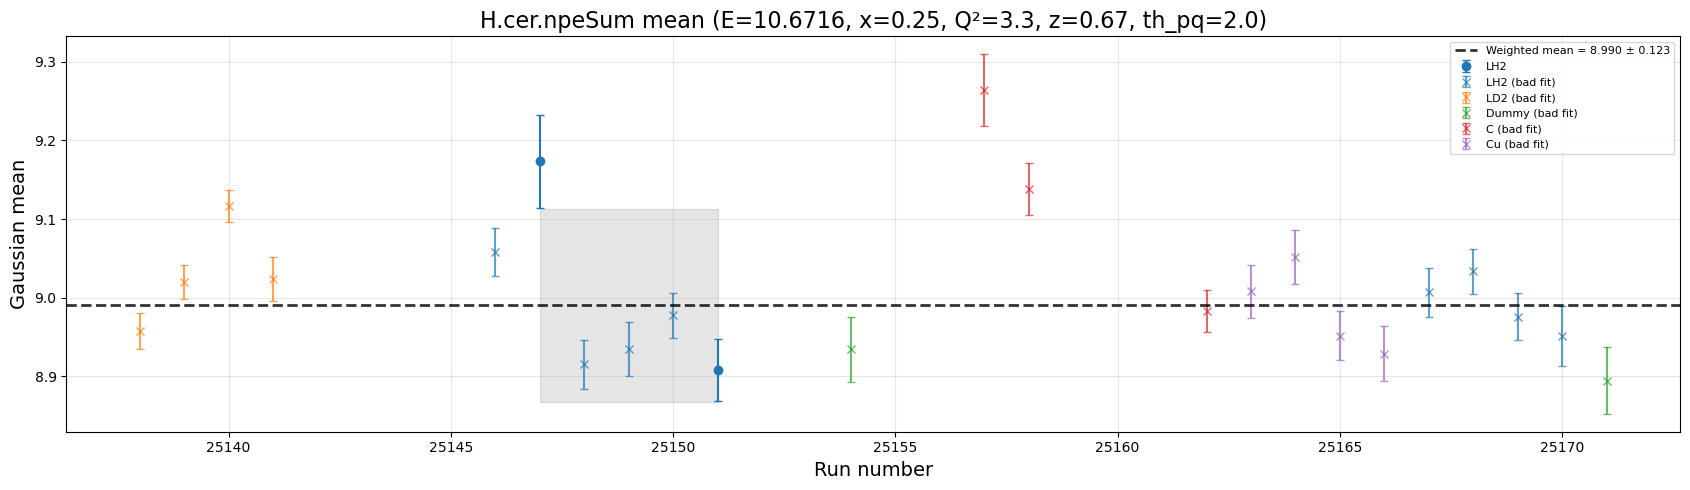

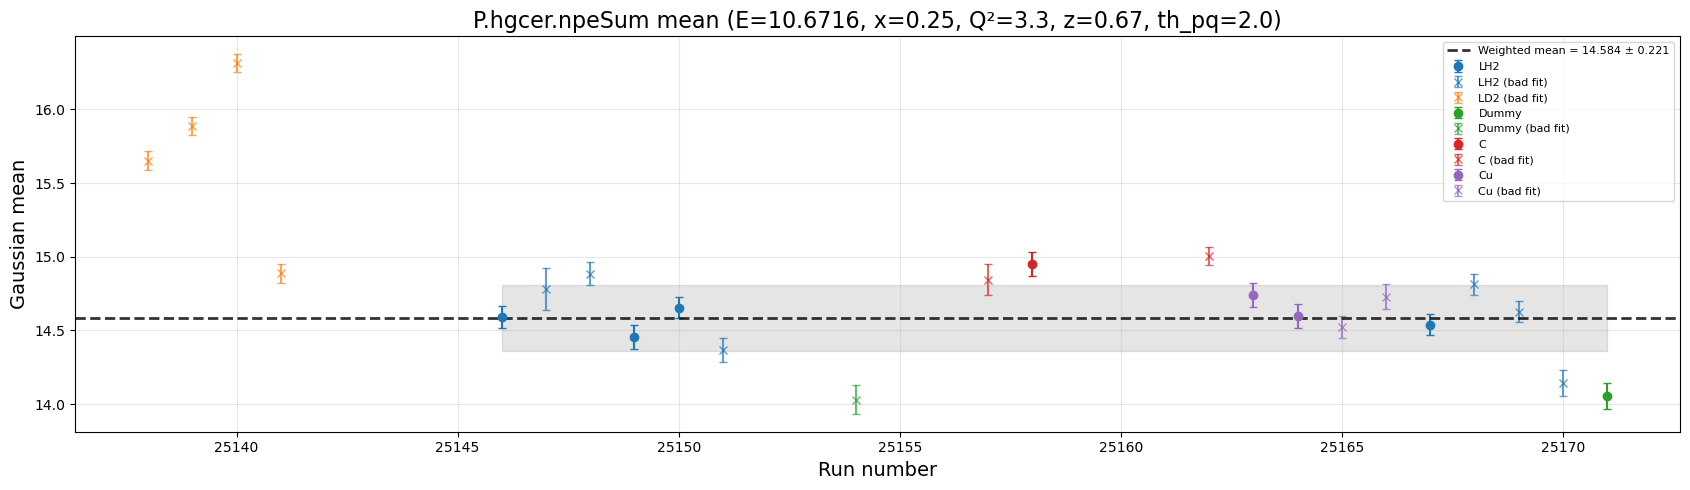

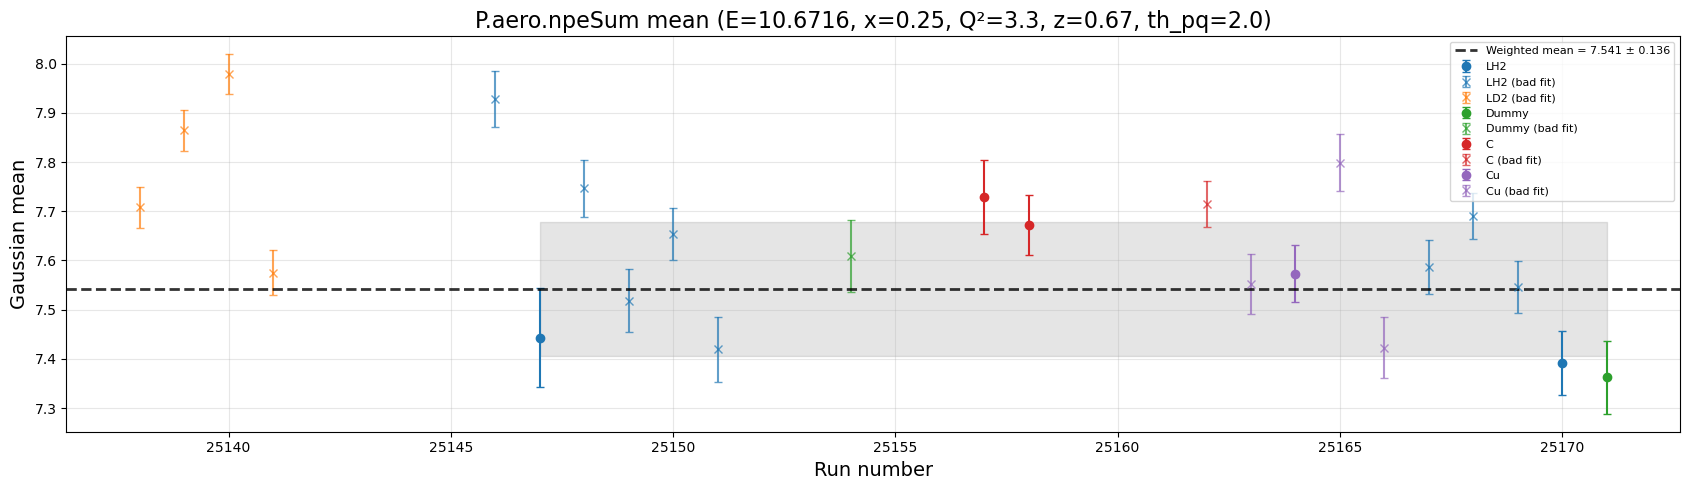

In [64]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.67
thpq = 2.0
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

### Setting 7:

H.cer Weighted Mean = 8.958 ± 0.289
P.hgcer Weighted Mean = 16.507 ± 0.338
P.aero Weighted Mean = 7.754 ± 0.287


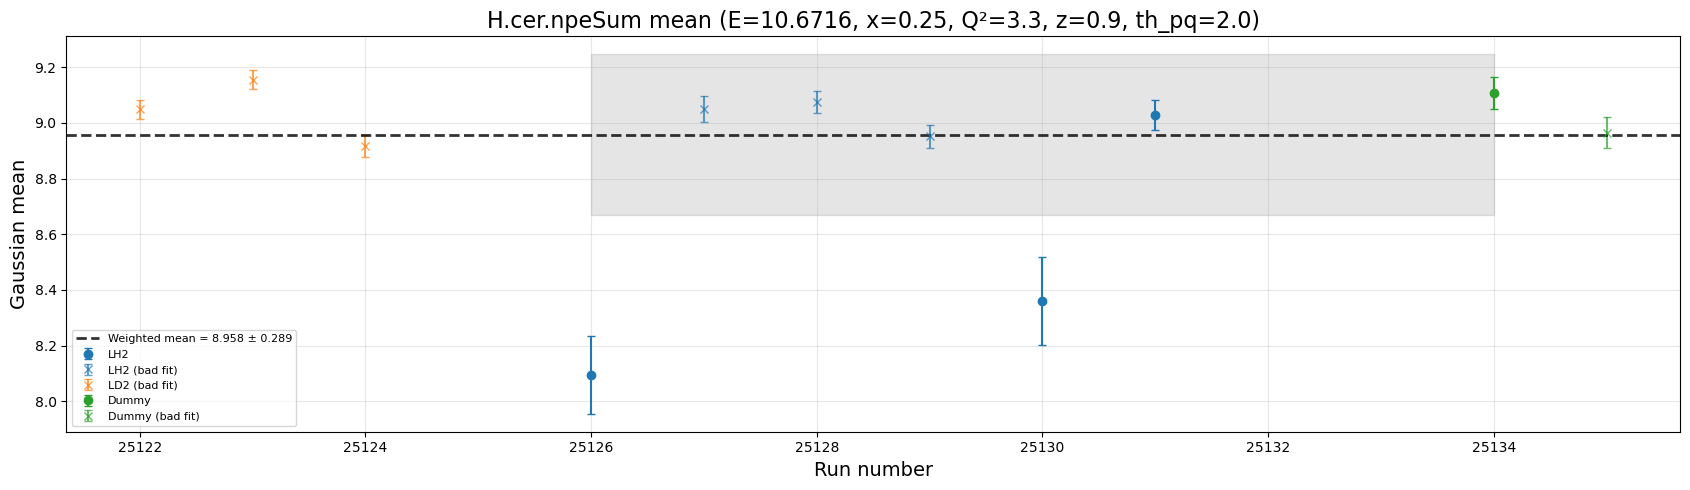

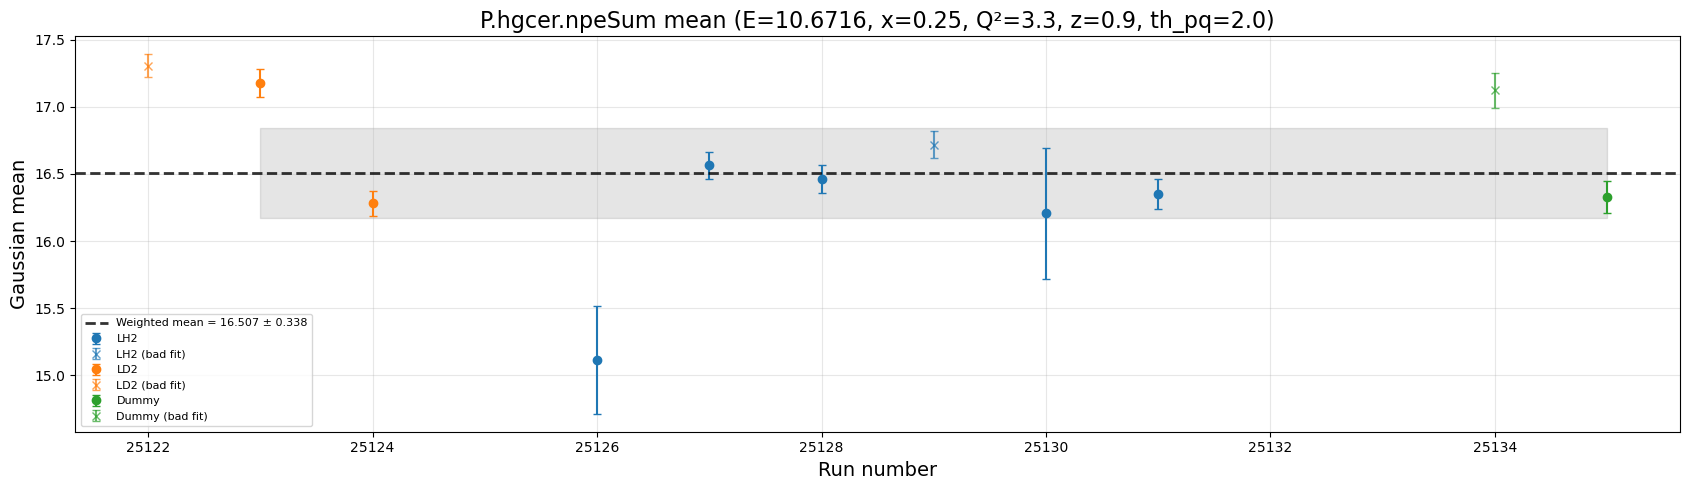

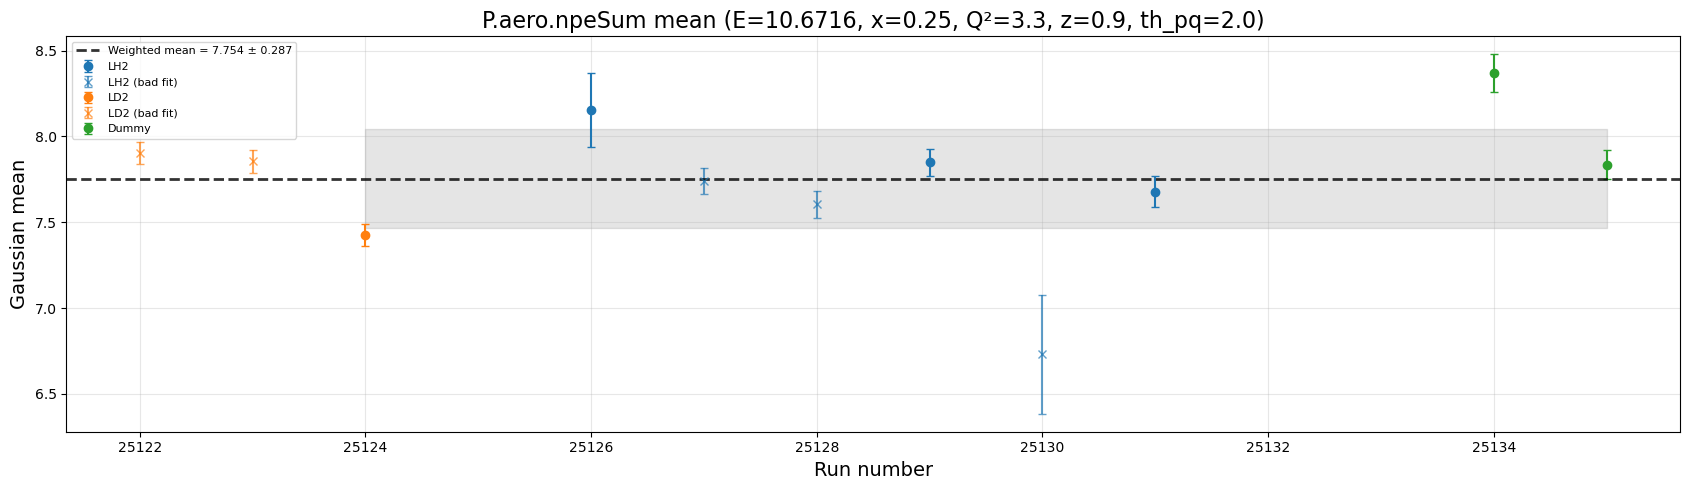

In [65]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.9
thpq = 2.0
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

### Settting 8

H.cer Weighted Mean = 9.052 ± 0.000
P.hgcer Weighted Mean = 8.939 ± 0.000
P.aero Weighted Mean = 7.208 ± 0.037


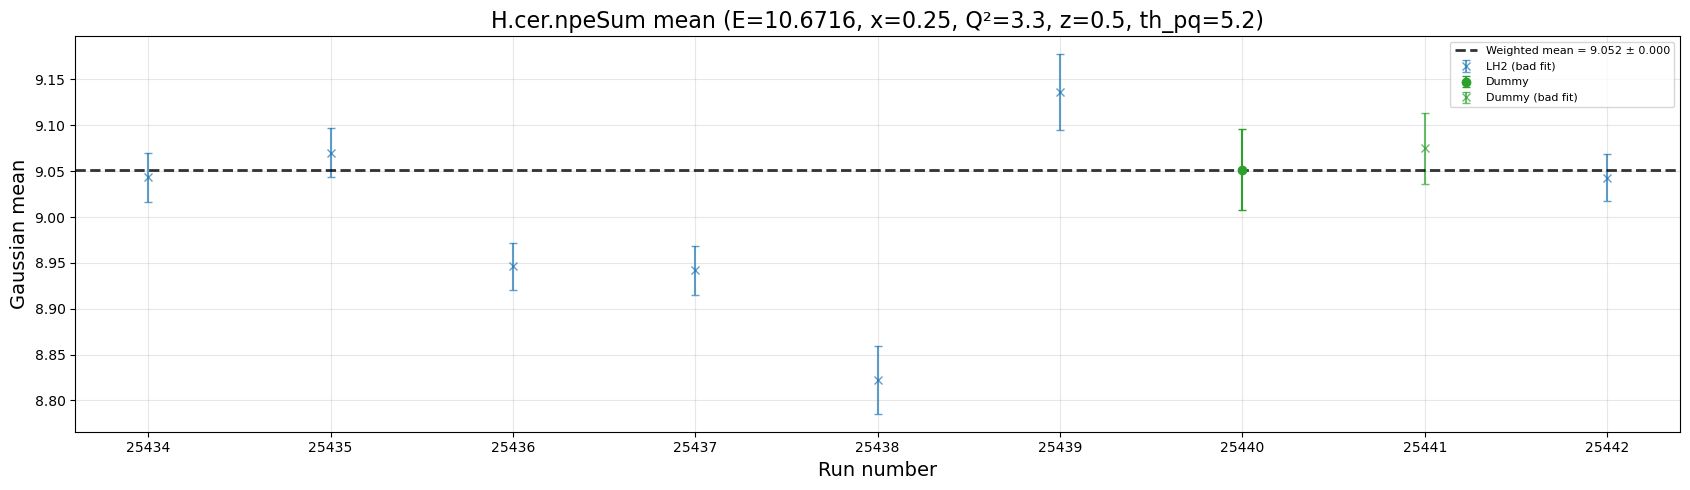

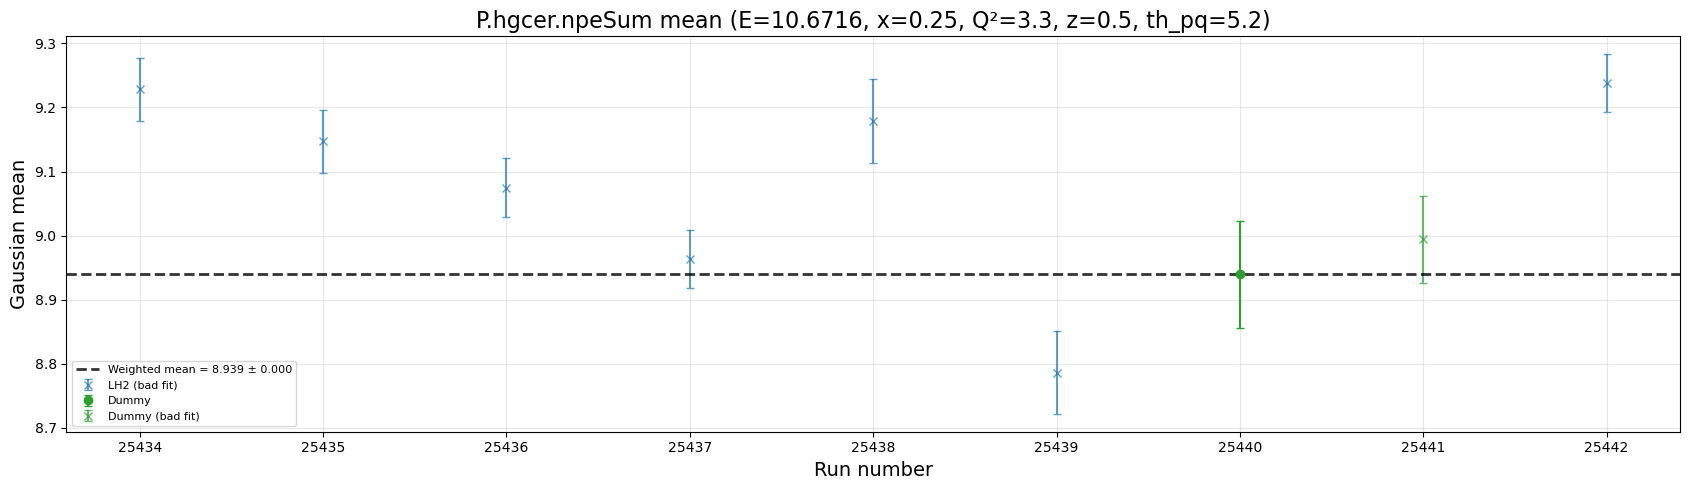

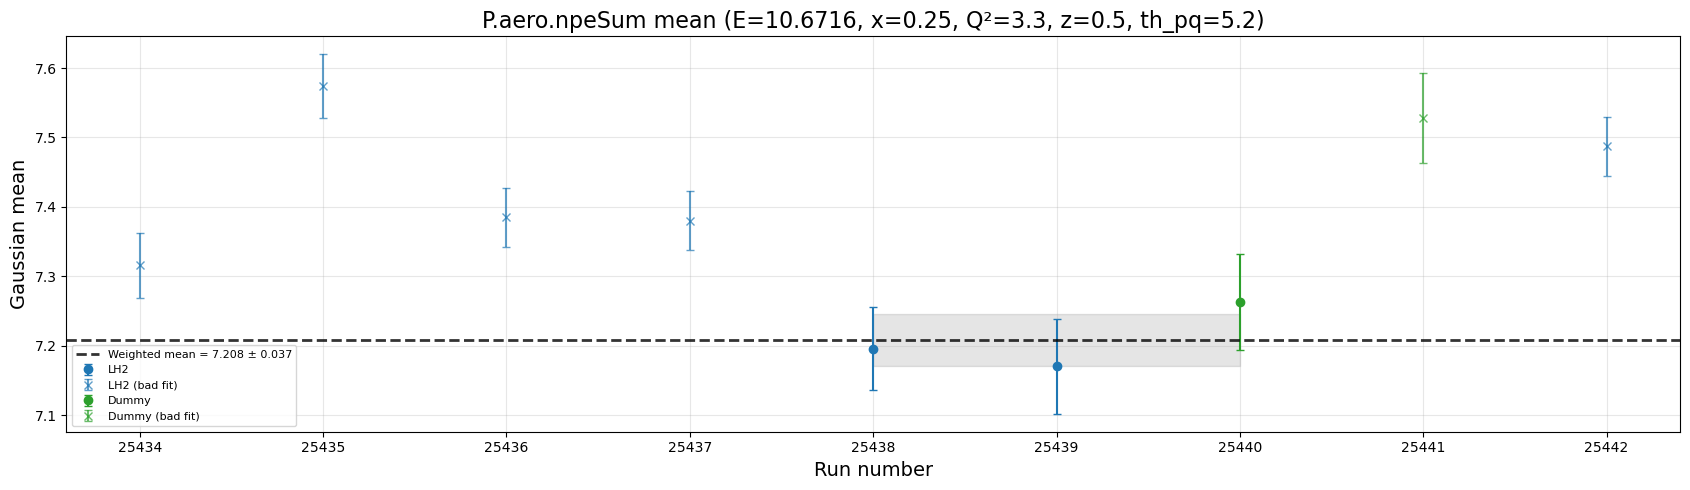

In [66]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 5.2
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

### Setting 9:

H.cer Weighted Mean = 8.970 ± 0.024
P.hgcer Weighted Mean = 8.764 ± 0.152
P.aero Weighted Mean = 7.307 ± 0.083


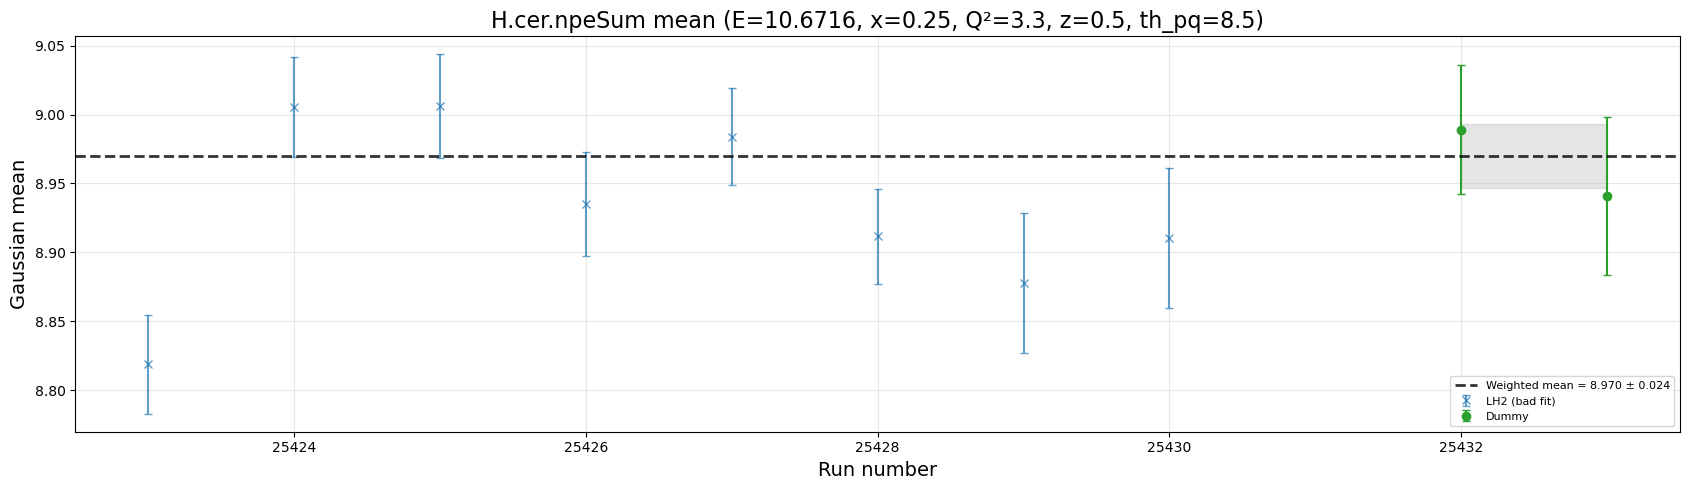

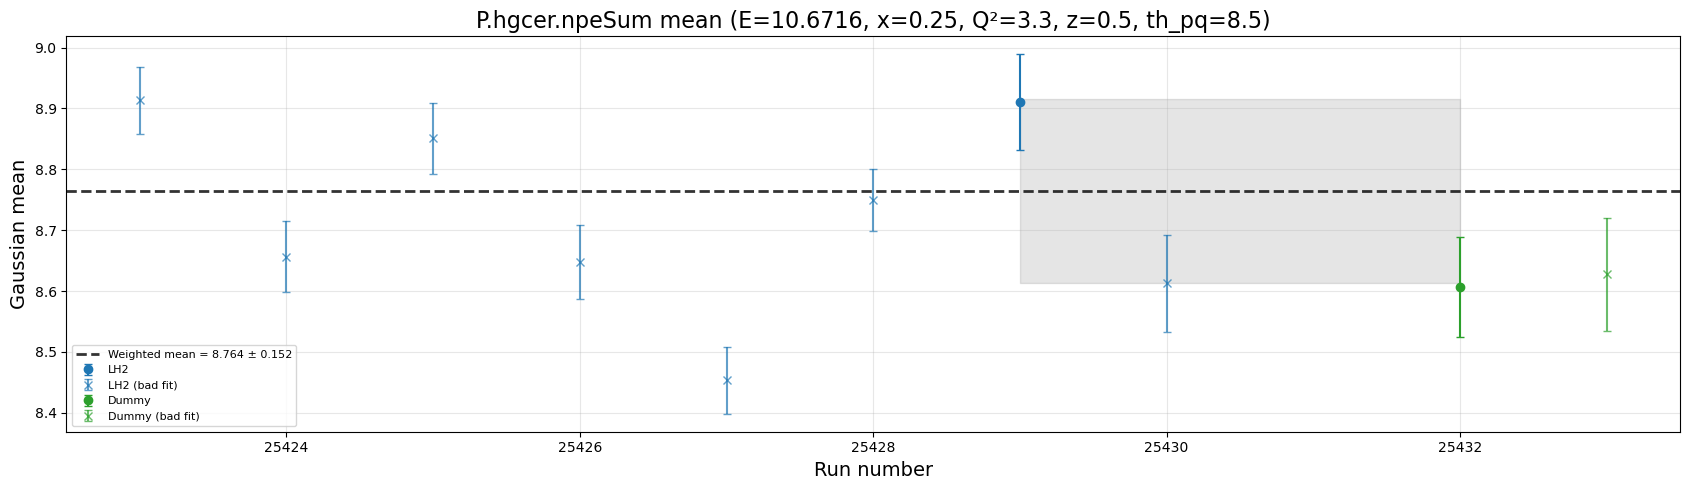

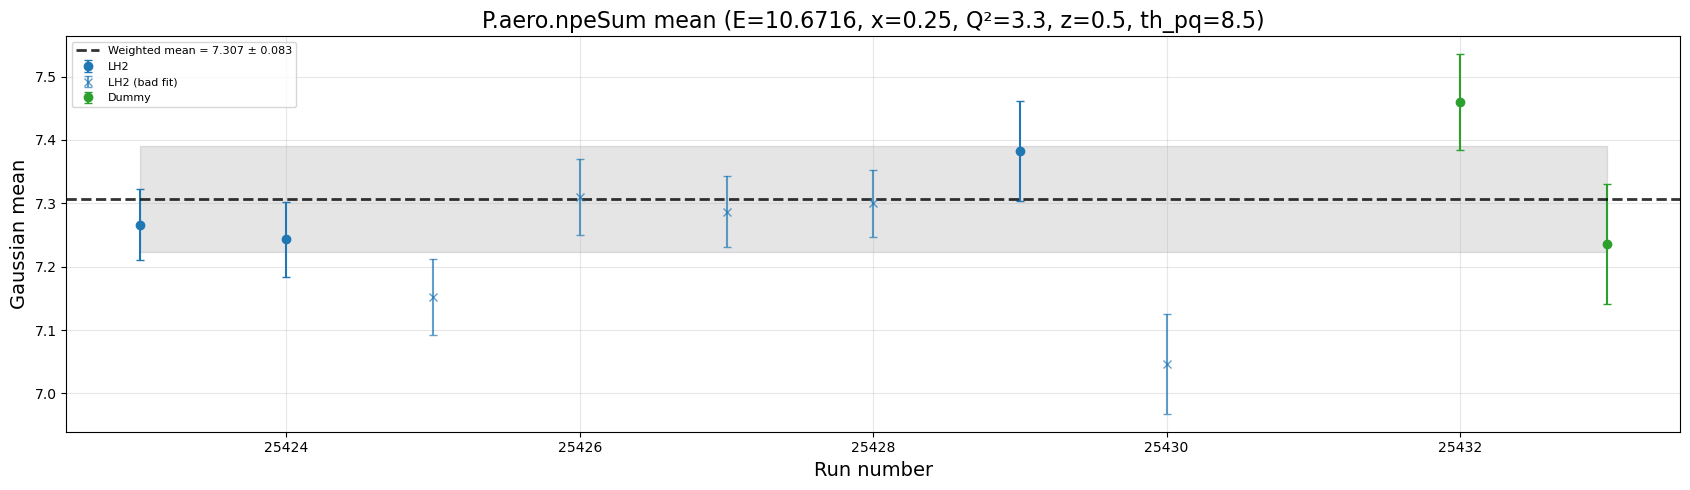

In [67]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 8.5
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

### $\pi^+$: Setting 1:

H.cer Weighted Mean = 8.971 ± 0.108
P.hgcer Weighted Mean = 1.251 ± 0.000
P.aero Weighted Mean = 6.563 ± 0.196


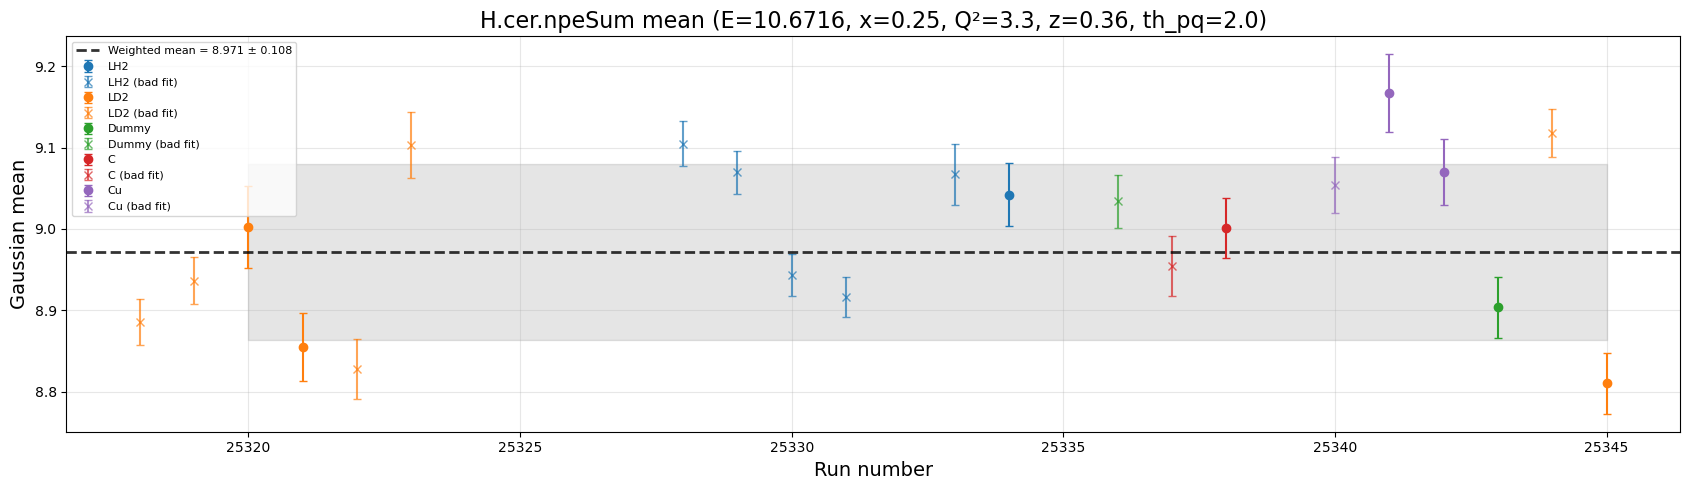

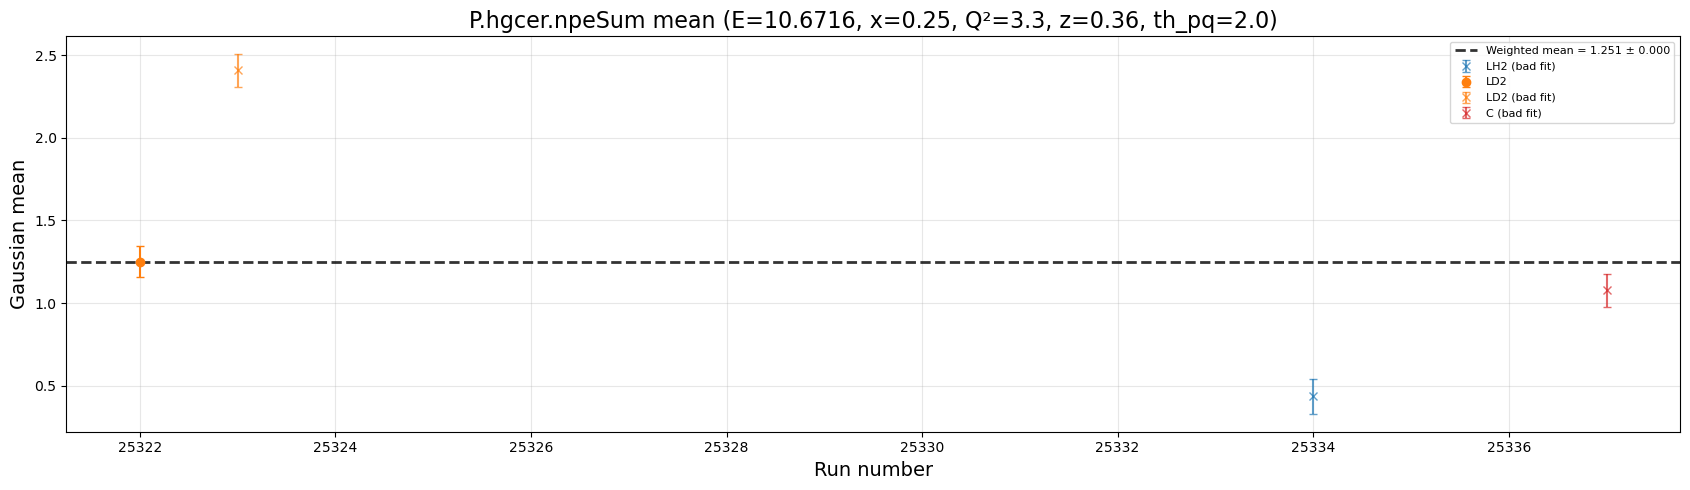

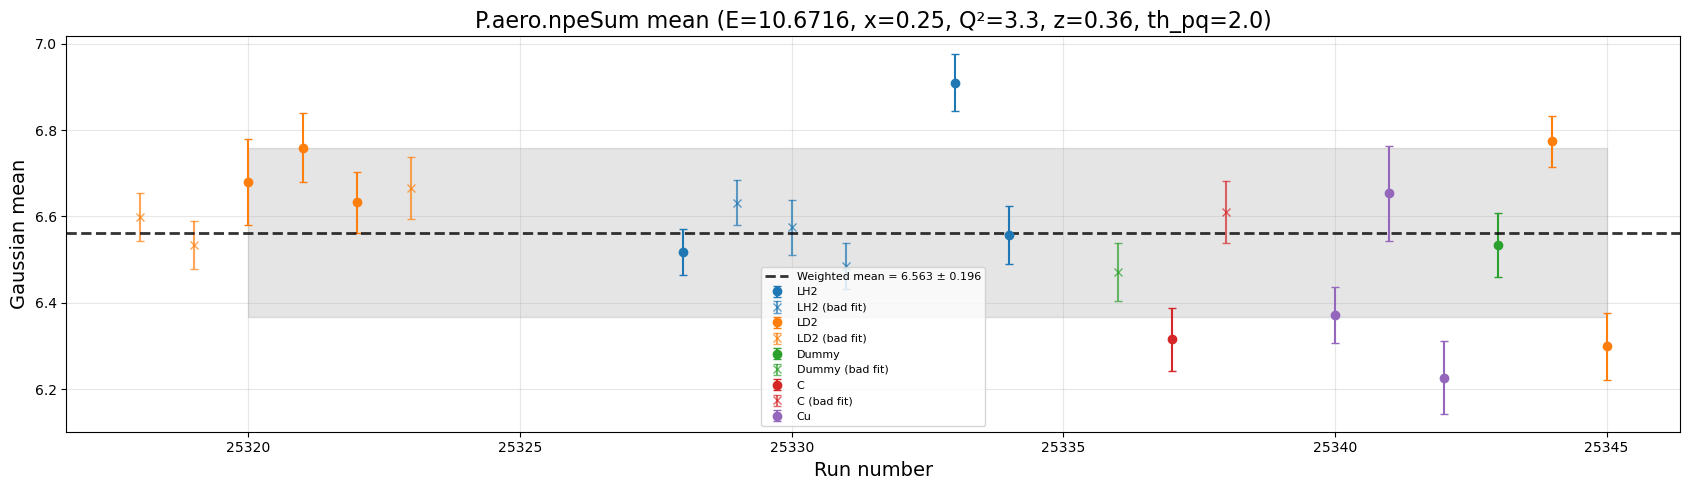

In [69]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.36
thpq = 2.0
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.3 < chi2ndf < 3.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

### Setting 2:

H.cer Weighted Mean = 8.932 ± 0.002
P.hgcer Weighted Mean = 9.258 ± 0.188
P.aero Weighted Mean = 6.597 ± 0.196


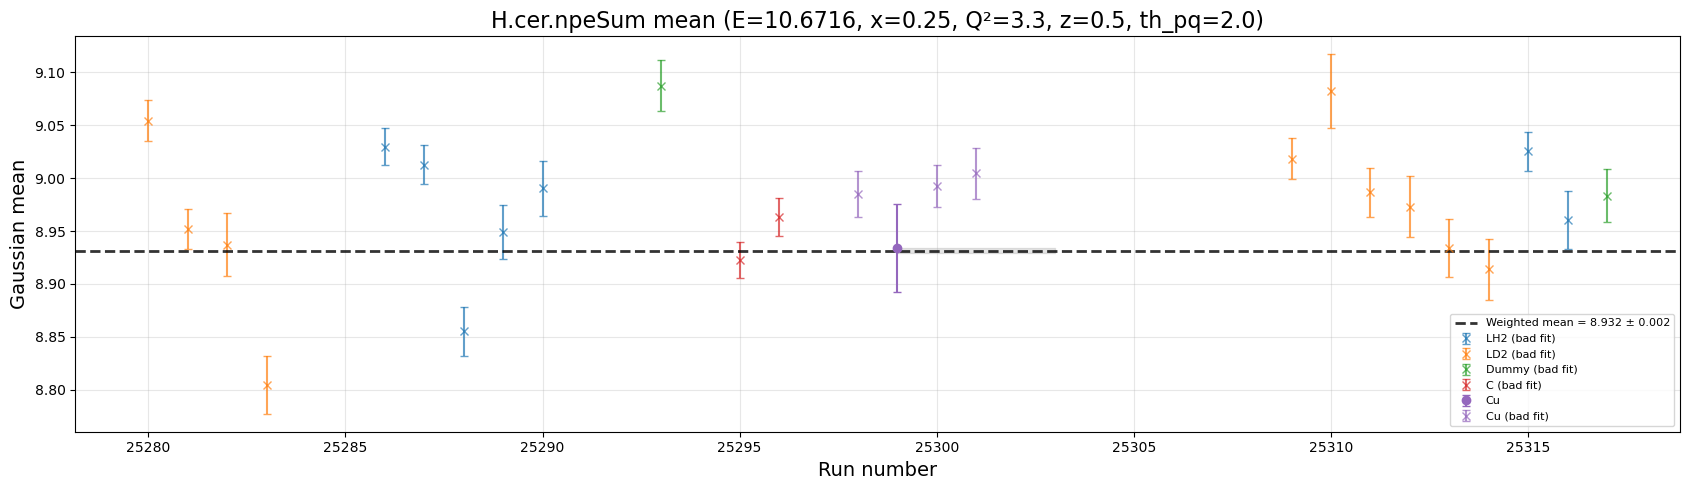

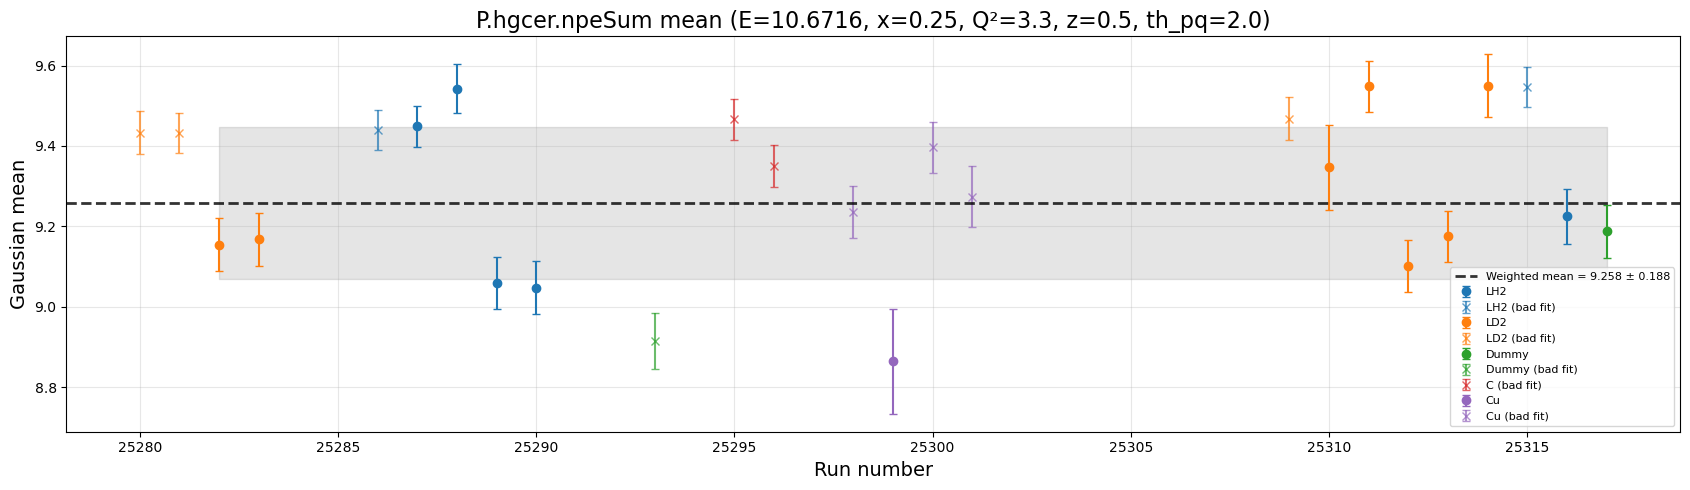

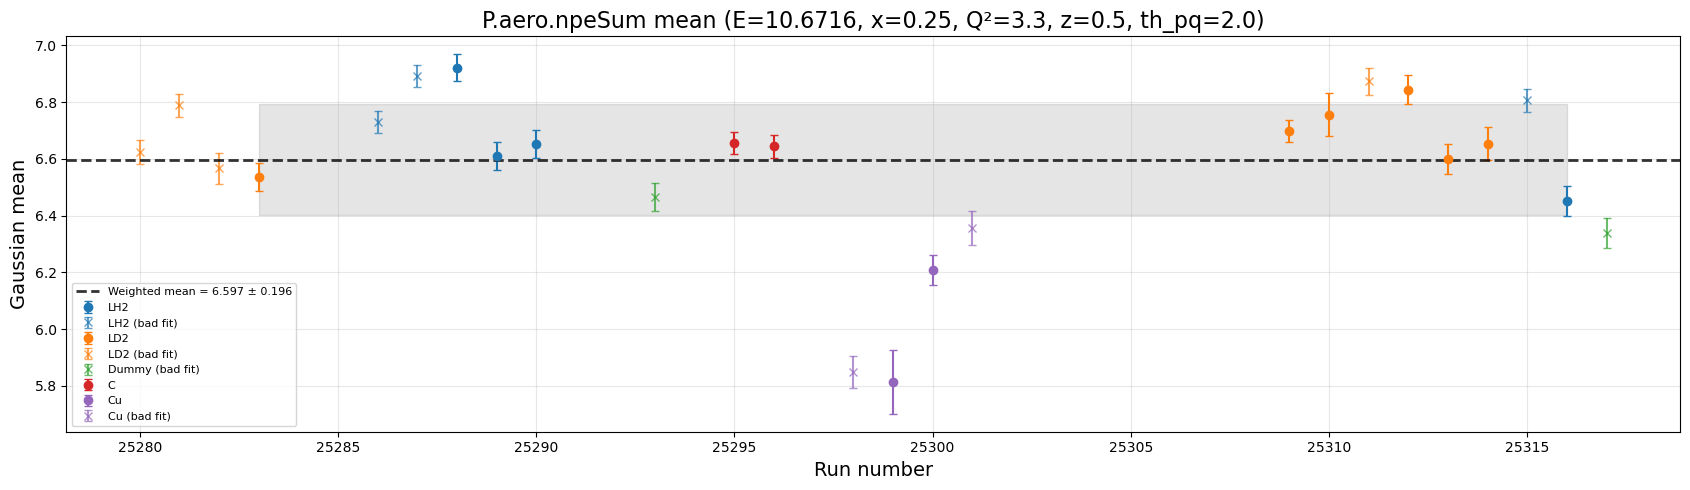

In [71]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 2.0
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.3 < chi2ndf < 3.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

### Setting 3:

H.cer Weighted Mean = 8.987 ± 0.060
P.hgcer Weighted Mean = 14.200 ± 0.238
P.aero Weighted Mean = 6.477 ± 0.210


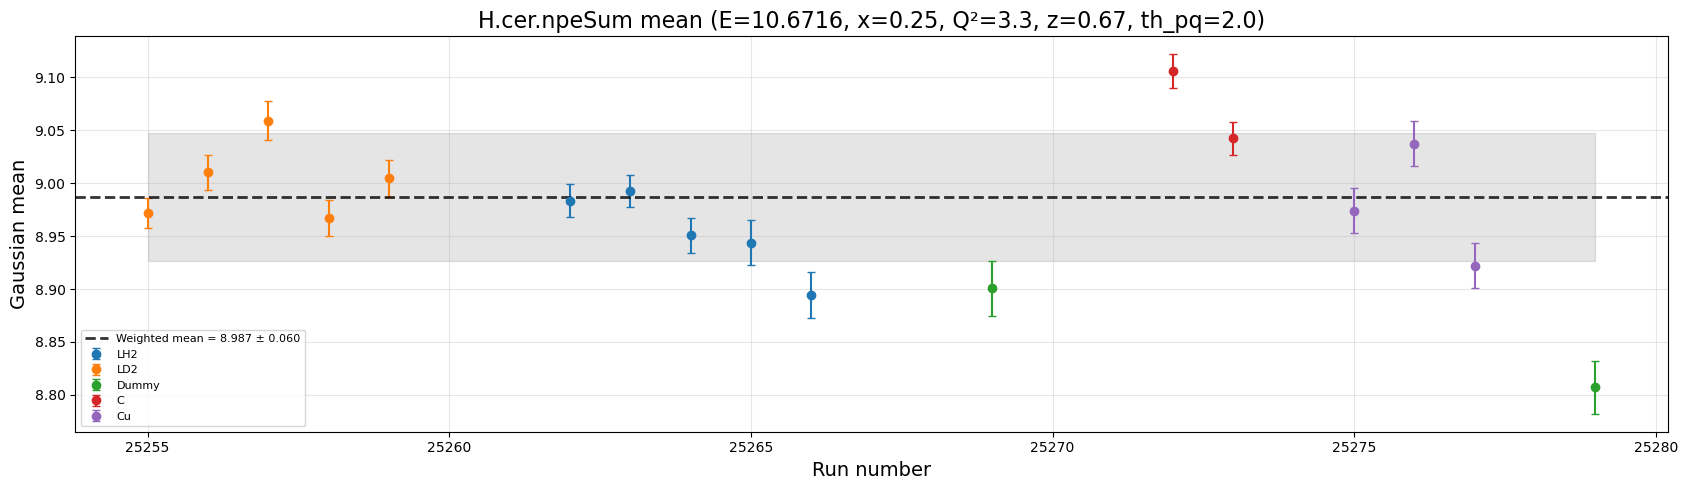

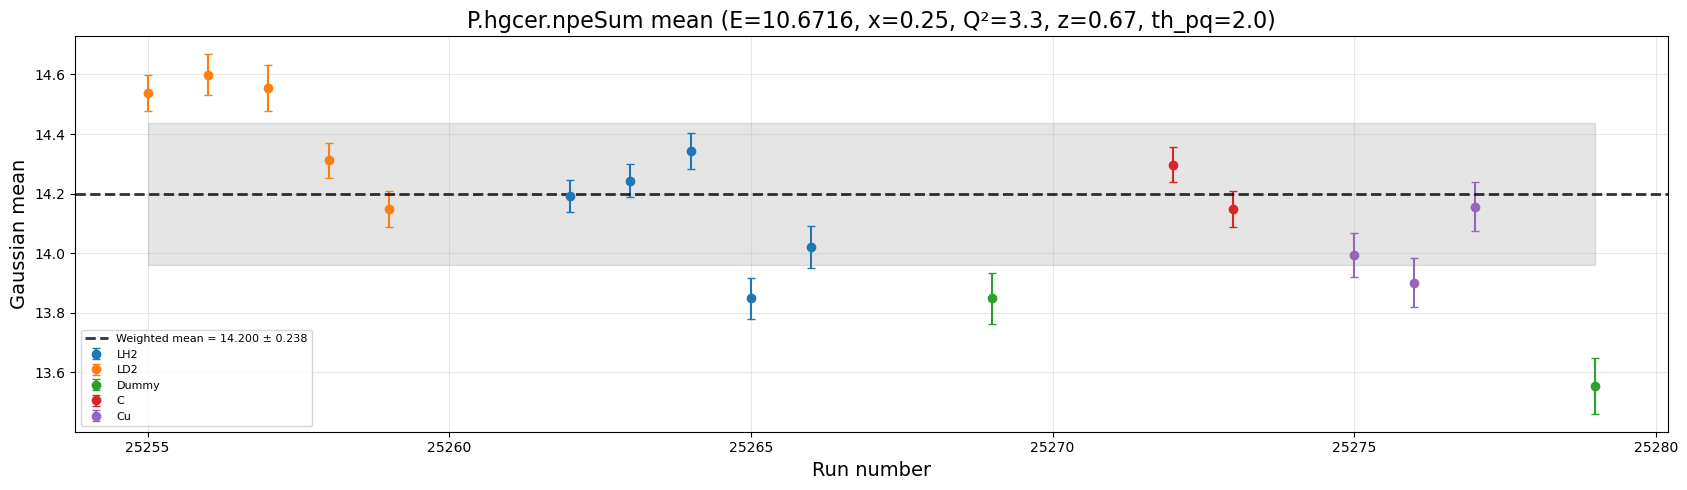

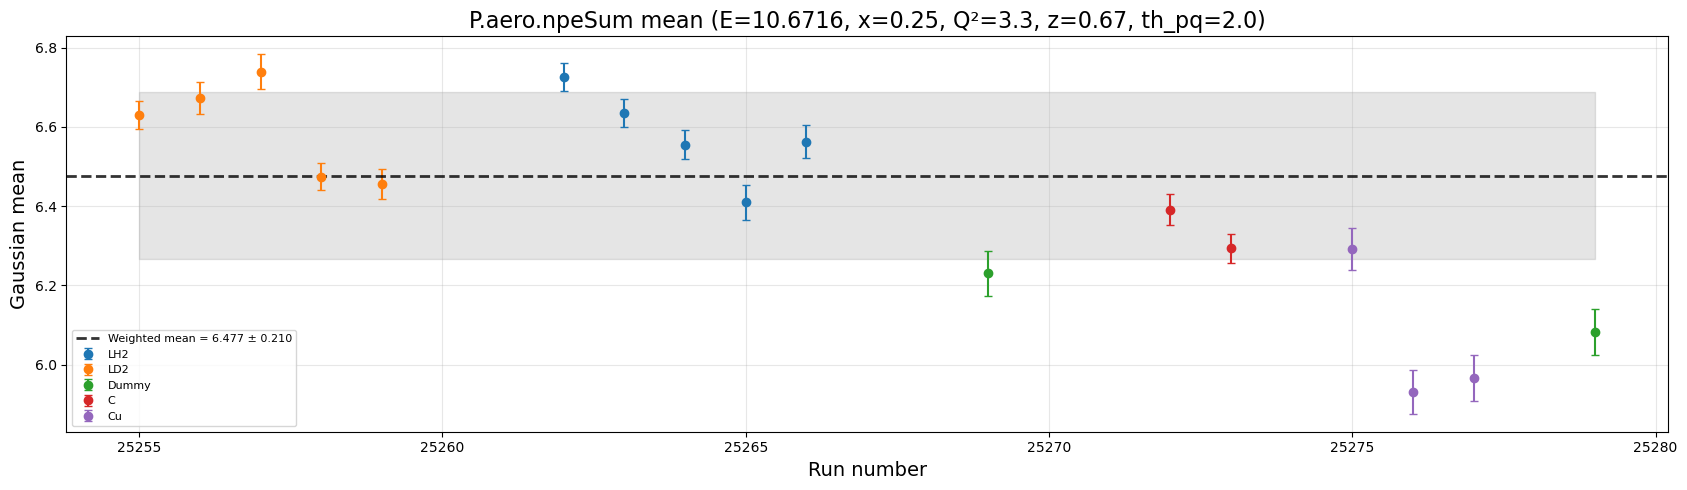

In [74]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.67
thpq = 2.0
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

### Setting 4:

H.cer Weighted Mean = 8.915 ± 0.000
P.hgcer Weighted Mean = 15.495 ± 0.208
P.aero Weighted Mean = 7.078 ± 0.136


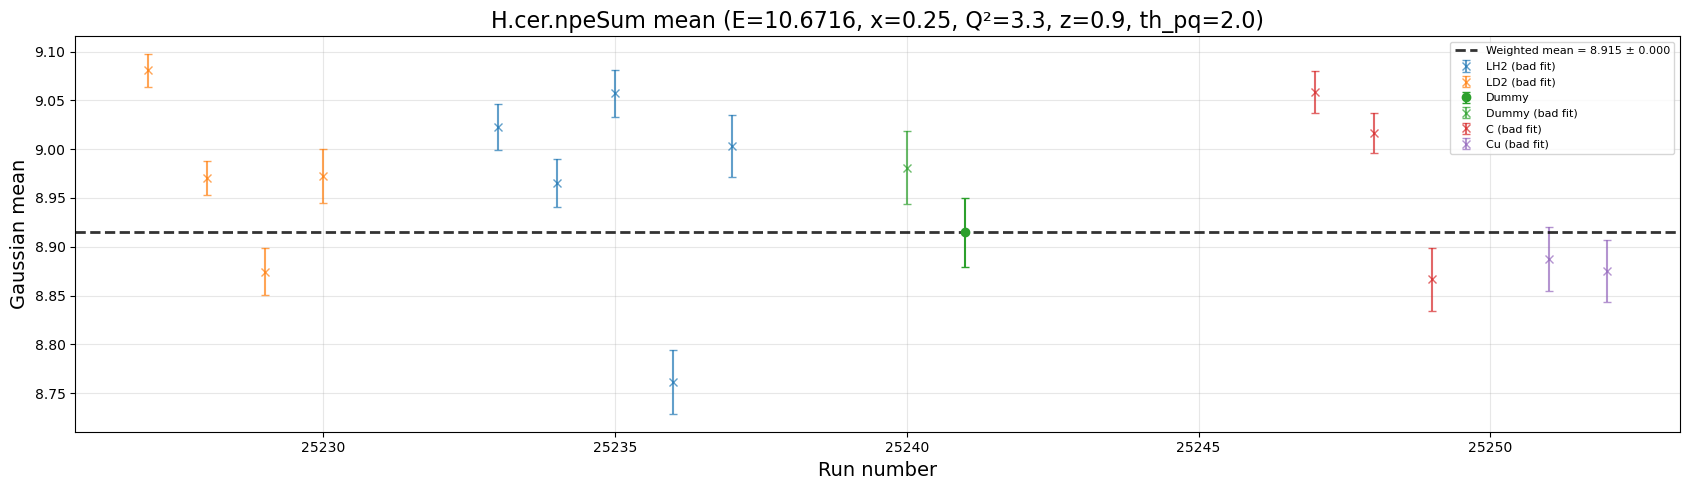

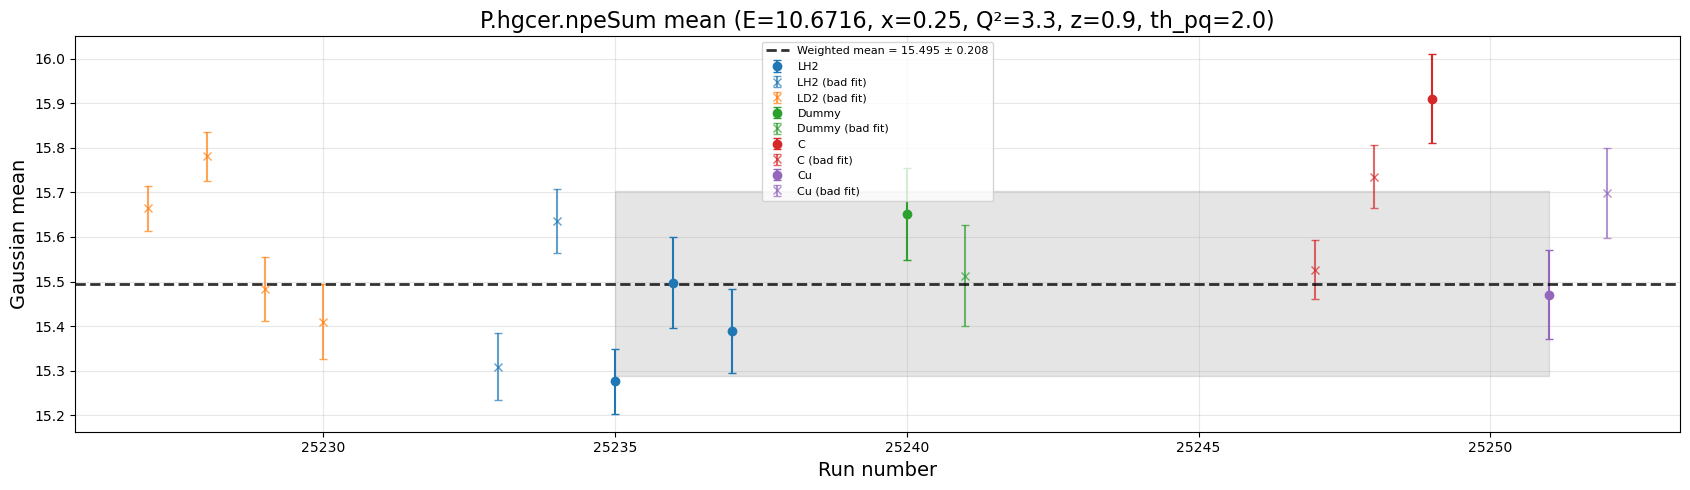

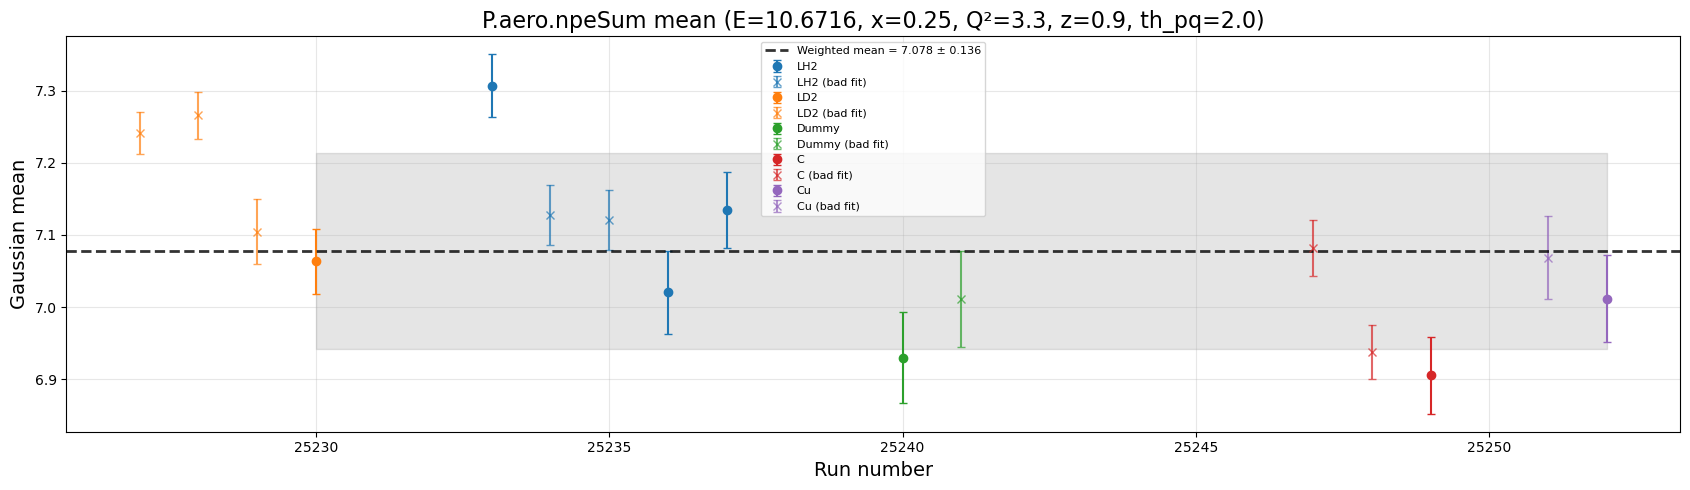

In [75]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.9
thpq = 2.0
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.3 < chi2ndf < 3.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

### Setting 5:

H.cer Weighted Mean = 9.087 ± 0.000
P.hgcer Weighted Mean = 8.927 ± 0.143
P.aero Weighted Mean = 6.559 ± 0.194


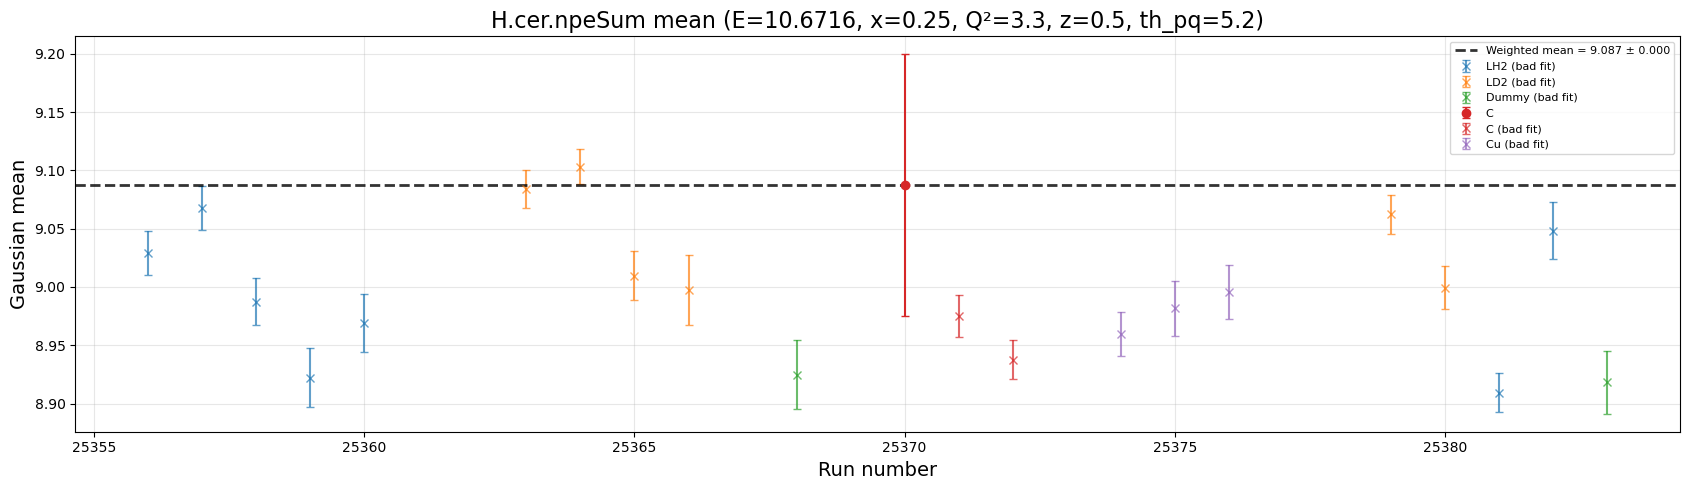

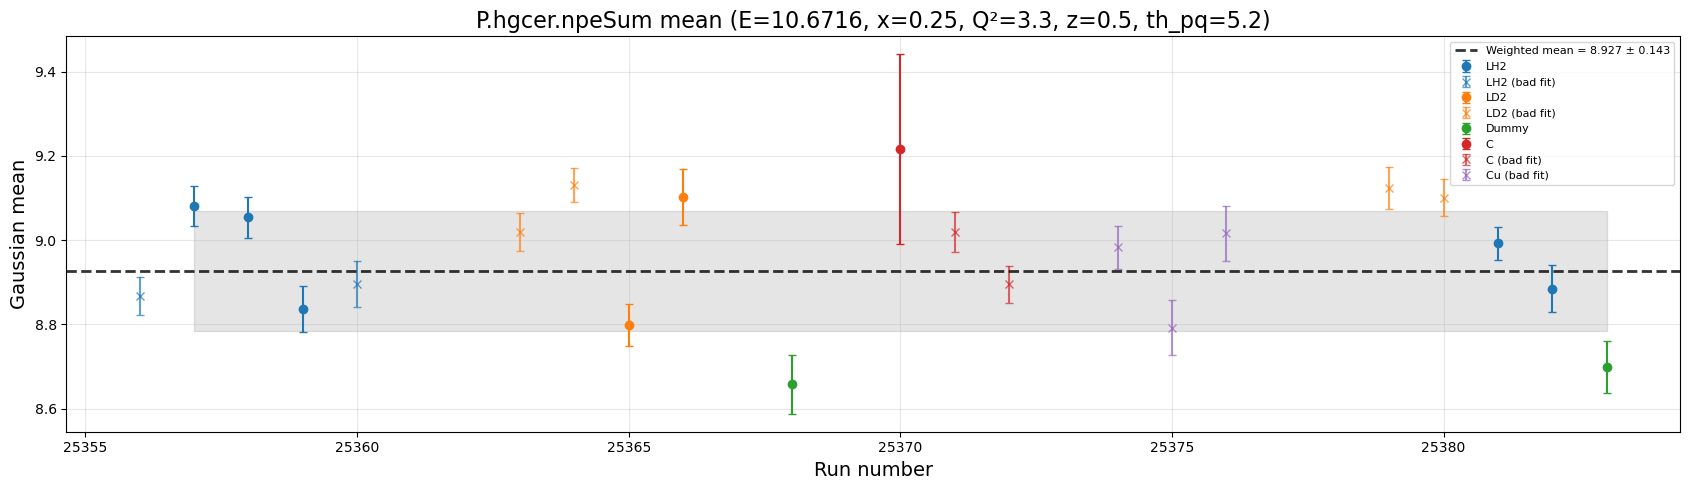

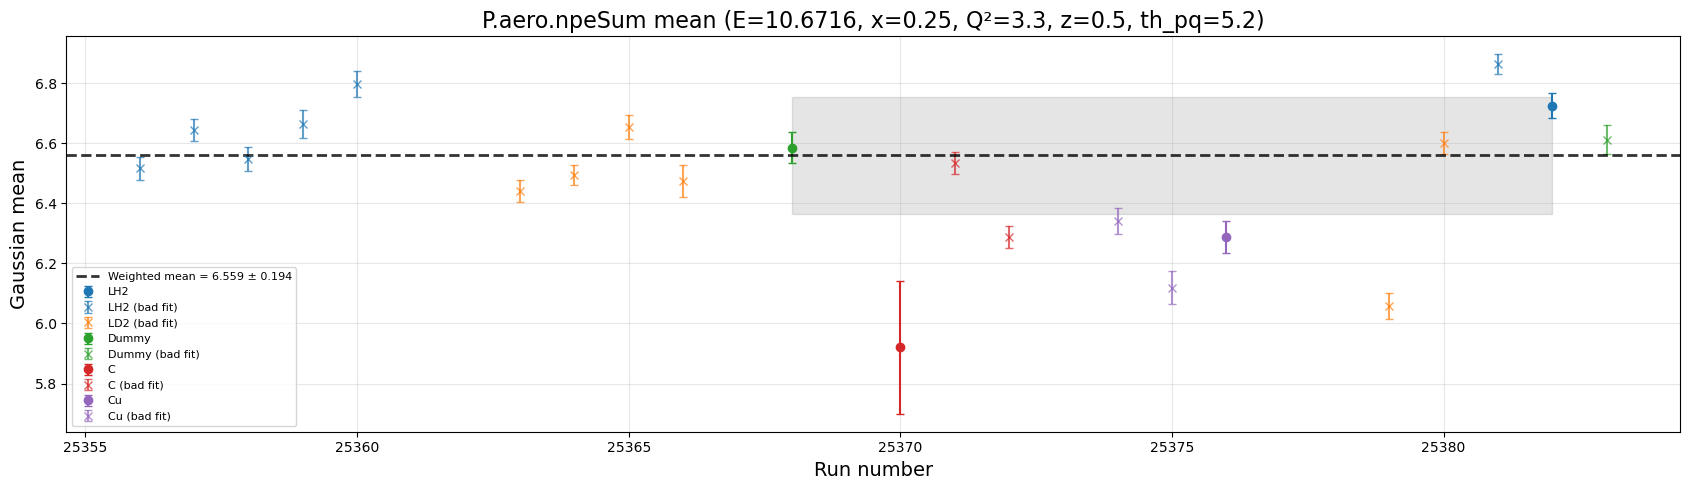

In [76]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 5.2
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.3 < chi2ndf < 3.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

H.cer Weighted Mean = 8.988 ± 0.021
P.hgcer Weighted Mean = 8.532 ± 0.132
P.aero Weighted Mean = 6.645 ± 0.159


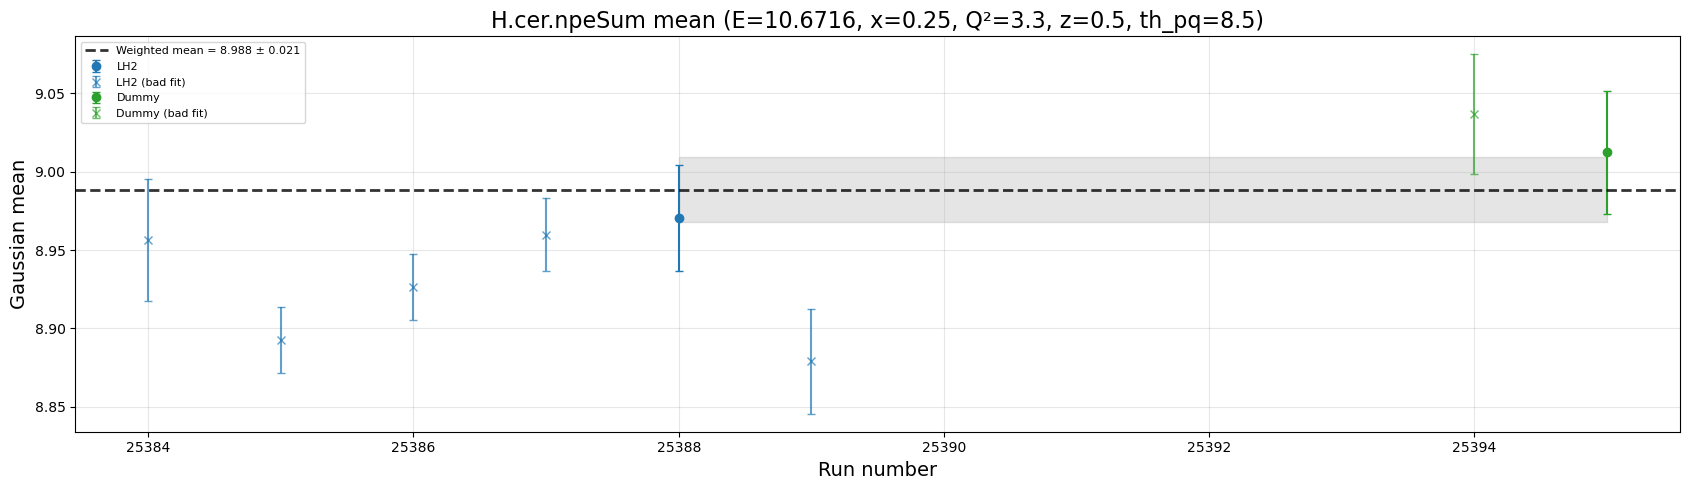

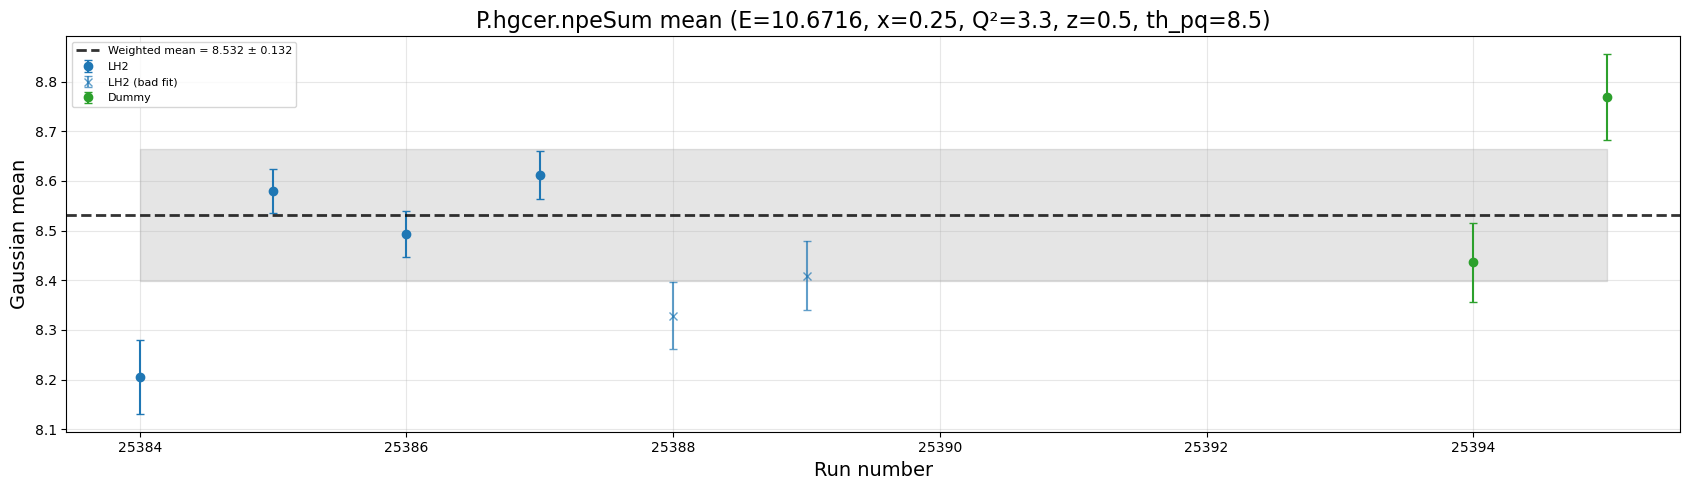

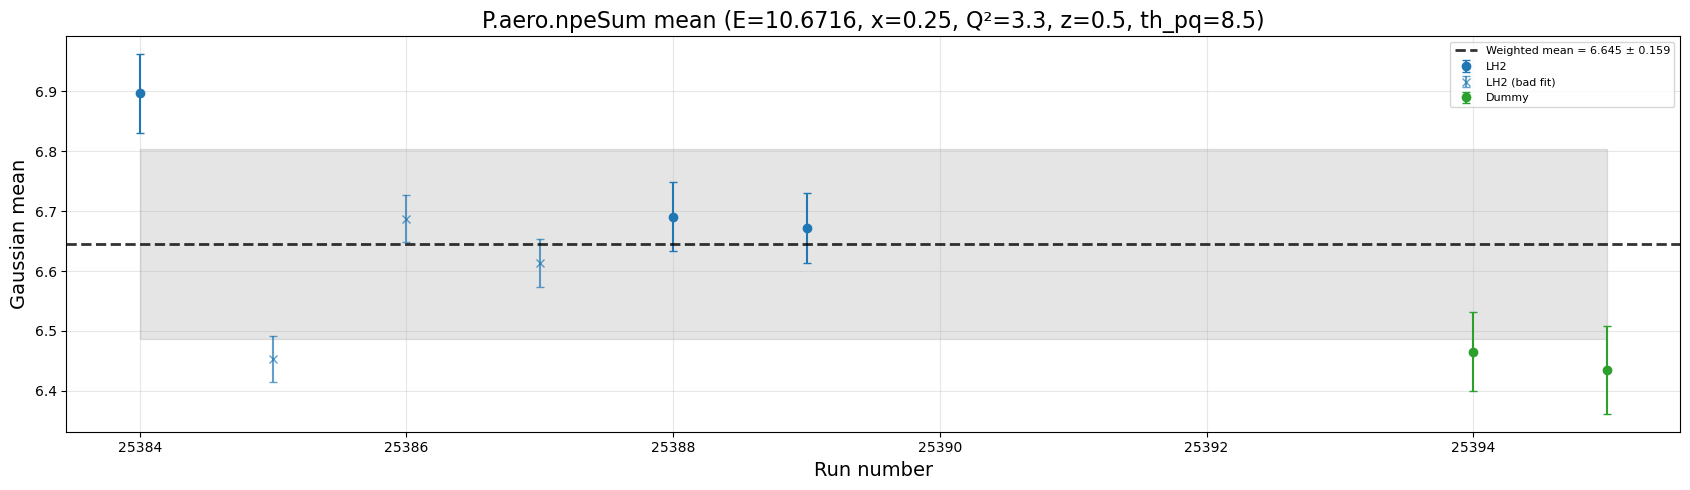

In [78]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 8.5
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.3 < chi2ndf < 3.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()